In [ ]:
# ------- [Import all relevant libraries] -------

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Usual Suspects
import numpy as np           # Mathematical operations
import pandas as pd          # Data manipulation

# Visualization
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns

# String manipulation
import re

# Mathematical Operations
import math

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# ML
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, 
    StratifiedKFold, cross_val_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ML Model Evaluation
import optuna
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, make_scorer, f1_score, 
    ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, 
    roc_auc_score, classification_report,
)

# Saving model for production
import joblib

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_colwidth', None)
from IPython.display import display

# MODELING

We will develop predictive models for H1N1 Vaccine Uptake and Seasonal Flu Vaccine Uptake independently.  
To ensure methodological rigor, the modeling workflow will proceed in three structured phases:

1. Baseline Modeling (Vanilla Iteration): We begin by training all selected classifiers using their default hyperparameters. This establishes foundational performance benchmarks, providing a reference point for evaluating subsequent enhancements.
2. Addressing Class Imbalance: Univariate exploration in the EDA phase revealed a significant imbalance in the target variable distributions. To mitigate this, techniques such as **class weighting** and **SMOTE oversampling** will be applied. Models will then be retrained to assess improvements in sensitivity to the minority class.
3. Hyperparameter Optimization: Once the strongest initial performers are identified, we will conduct targeted hyperparameter tuning to maximize predictive power, stability, and generalization capability.

#### Selected Classifiers

To capture a broad spectrum of learning behaviors, the following algorithms will be employed:

- **Logistic Regression** – Provides strong interpretability and serves as a robust linear baseline.  
- **Decision Trees** – Captures hierarchical, rule-based relationships.  
- **Random Forest** – Handles non-linearity and feature interactions effectively.  
- **XGBoost** – A high-performance boosting algorithm well suited for structured data.  
- **CatBoost** – Optimized for categorical variables with strong default performance.  
- **Neural Networks** – Capable of modelling complex, non-linear feature interactions.

This selection offers a balanced blend of interpretability, flexibility, and predictive strength.

## DATA PREPARATION

Prior to training, the dataset will undergo the following preprocessing procedures:

- Separate the target variable from the feature set.  
- Encode categorical features using appropriate techniques (e.g., one-hot, ordinal, or CatBoost encoding).  
- Scale numerical variables to ensure model stability and comparability.  
- Conduct a multicollinearity assessment using **Variance Inflation Factor (VIF)**.  
- Remove redundant or highly correlated features based on VIF outcomes.

In [3]:
# Create a copy to avoid modifying original
data = pd.read_csv("../Data/modeling_data.csv")

# Create a copy
df = data.copy(deep=True)

# --- IDE ---

# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check columns
print('\n'+'=='*44)
print("Columns:")
display(df.columns)

# Check metadata
print('\n'+'=='*44)
print("Metadata Check:")
display(df.info())

# Check and remove duplicates
print('\n'+'=='*44)
print("Duplicates:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)
print("Duplicates after dropping:", df.duplicated().sum())

# Check data completeness
print('\n'+'=='*44)
print("Missingness check:")
display(df.isna().sum())

The dataset has 26707 rows and 34 columns.

Columns:


Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'h1n1_vaccine',
       'seasonal_vaccine'],
      dtype='object')


Metadata Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26707 non-null  float64
 1   h1n1_knowledge               26707 non-null  float64
 2   behavioral_antiviral_meds    26707 non-null  float64
 3   behavioral_avoidance         26707 non-null  float64
 4   behavioral_face_mask         26707 non-null  float64
 5   behavioral_wash_hands        26707 non-null  float64
 6   behavioral_large_gatherings  26707 non-null  float64
 7   behavioral_outside_home      26707 non-null  float64
 8   behavioral_touch_face        26707 non-null  float64
 9   doctor_recc_h1n1             26707 non-null  float64
 10  doctor_recc_seasonal         26707 non-null  float64
 11  chronic_med_condition        26707 non-null  float64
 12  child_under_6_months         26707 non-null  float64
 13 

None


Duplicates: 1
Duplicates after dropping: 0

Missingness check:


h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
hhs_geo_region                 0
census_msa                     0
household_

We will start by predicting H1N1 Vaccine

In [4]:
# ------- [PREPROCESSING PIPELINE] -------

# Separate features and target
X = df.drop('h1n1_vaccine', axis=1)
y = df['h1n1_vaccine']

# Identify feature types
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# Fit pipeline
X_processed = preprocessor.fit_transform(X)

# Extract transformed column names
encoded_cat_cols = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
processed_feature_names = num_cols + list(encoded_cat_cols)

# Convert to DataFrame
df_processed = pd.DataFrame(X_processed, columns=processed_feature_names)

# Compute VIF
df_vif = df_processed.copy()
df_vif['intercept'] = 1 

vif_df = pd.DataFrame({
    'feature': df_vif.columns,
    'VIF': [
        variance_inflation_factor(df_vif.values, i)
        for i in range(df_vif.shape[1])
    ]
})

display(vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True))

,feature,VIF
0,intercept,54.854154
1,education_Graduate,4.222907
2,education_Some College,3.303439
3,education_HS Grad,2.862226
4,age_group_65+,2.860089
5,hhs_geo_region_lzgpxyit,2.678592
6,race_White,2.614961
7,hhs_geo_region_fpwskwrf,2.356300
8,hhs_geo_region_qufhixun,2.258785
9,hhs_geo_region_bhuqouqj,2.188467


## VANILLA MODELS

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.852322,0.852303,0.842773,0.842374,0.852322,0.852303,0.843887,0.842781,0.873484,0.864854
1,Random Forest,1.000000,0.851741,1.000000,0.841525,1.000000,0.851741,1.000000,0.838764,1.000000,0.860071
2,XGBoost,0.936248,0.844253,0.935219,0.834494,0.936248,0.844253,0.934387,0.836793,0.974230,0.861784
3,CatBoost,0.911955,0.851928,0.909674,0.842751,0.911955,0.851928,0.908100,0.844336,0.950298,0.871327


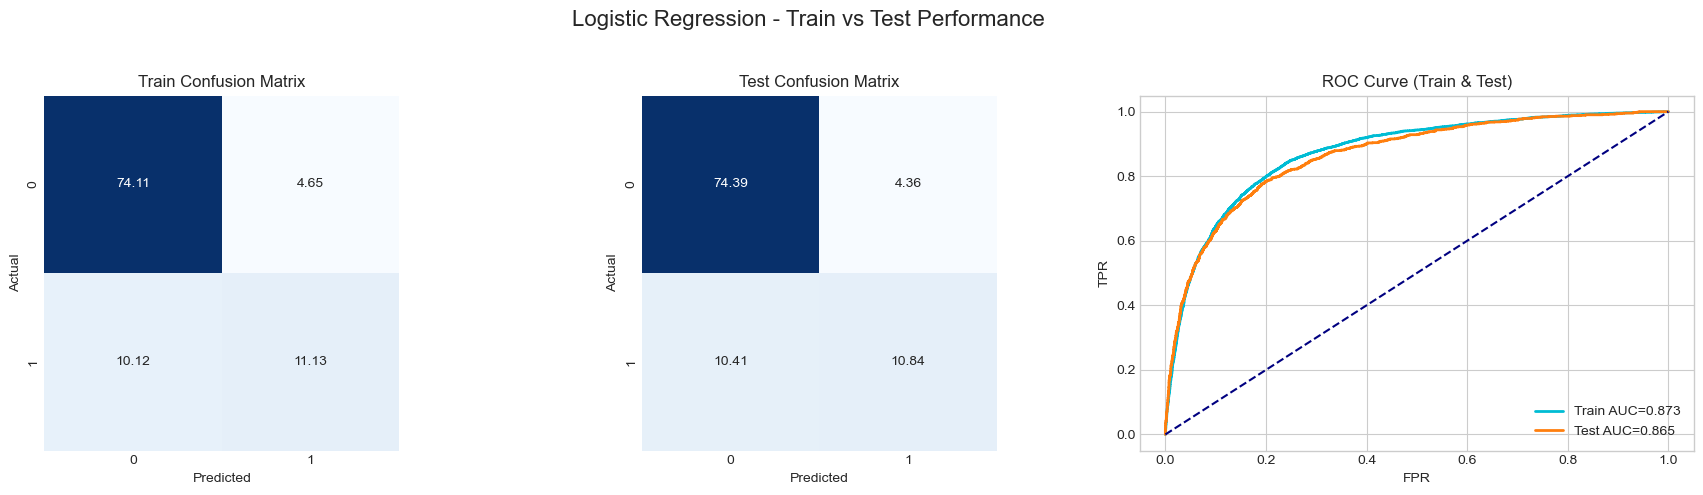

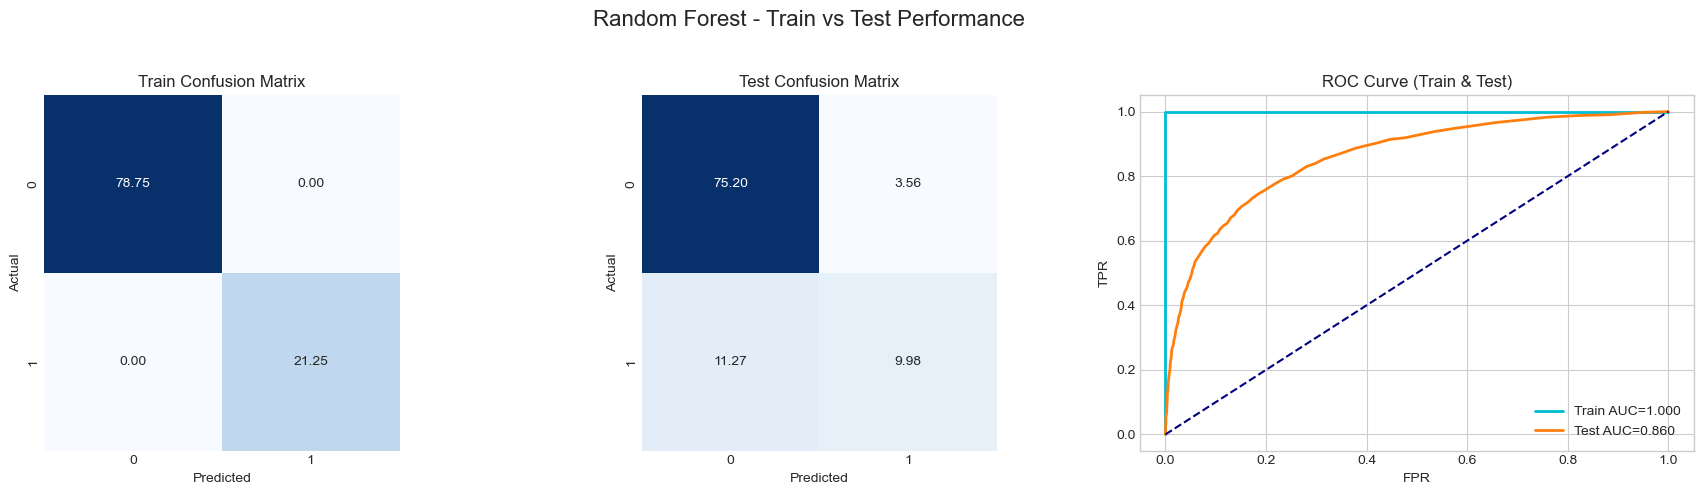

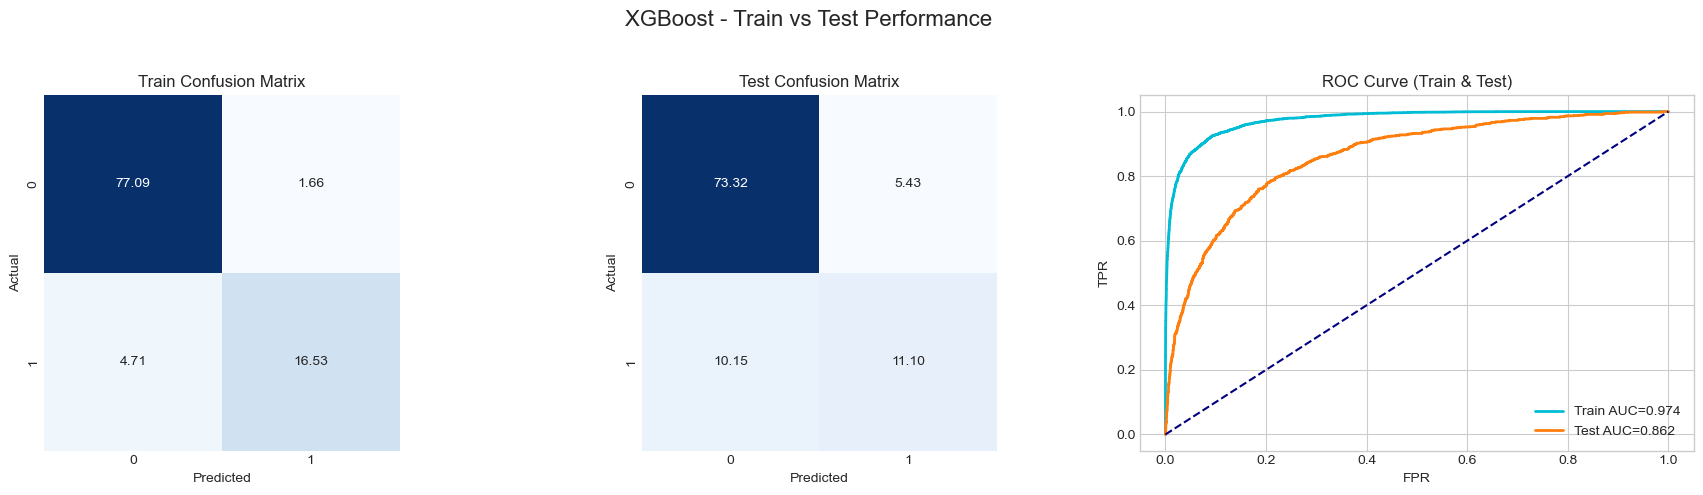

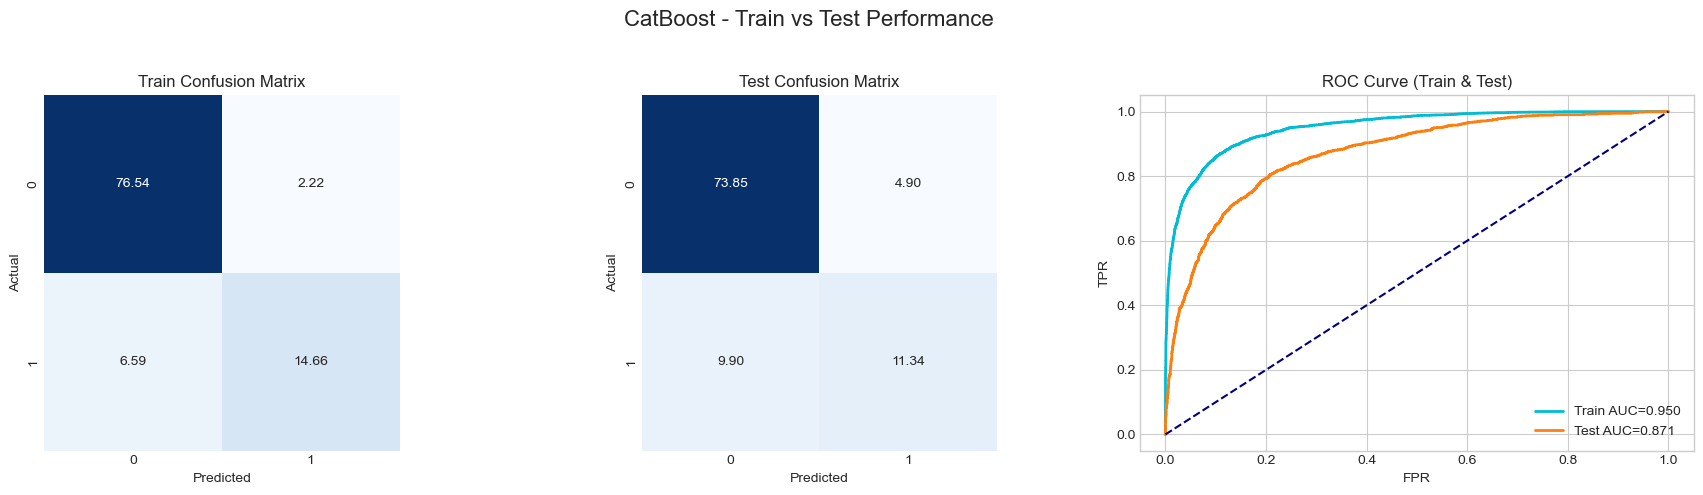

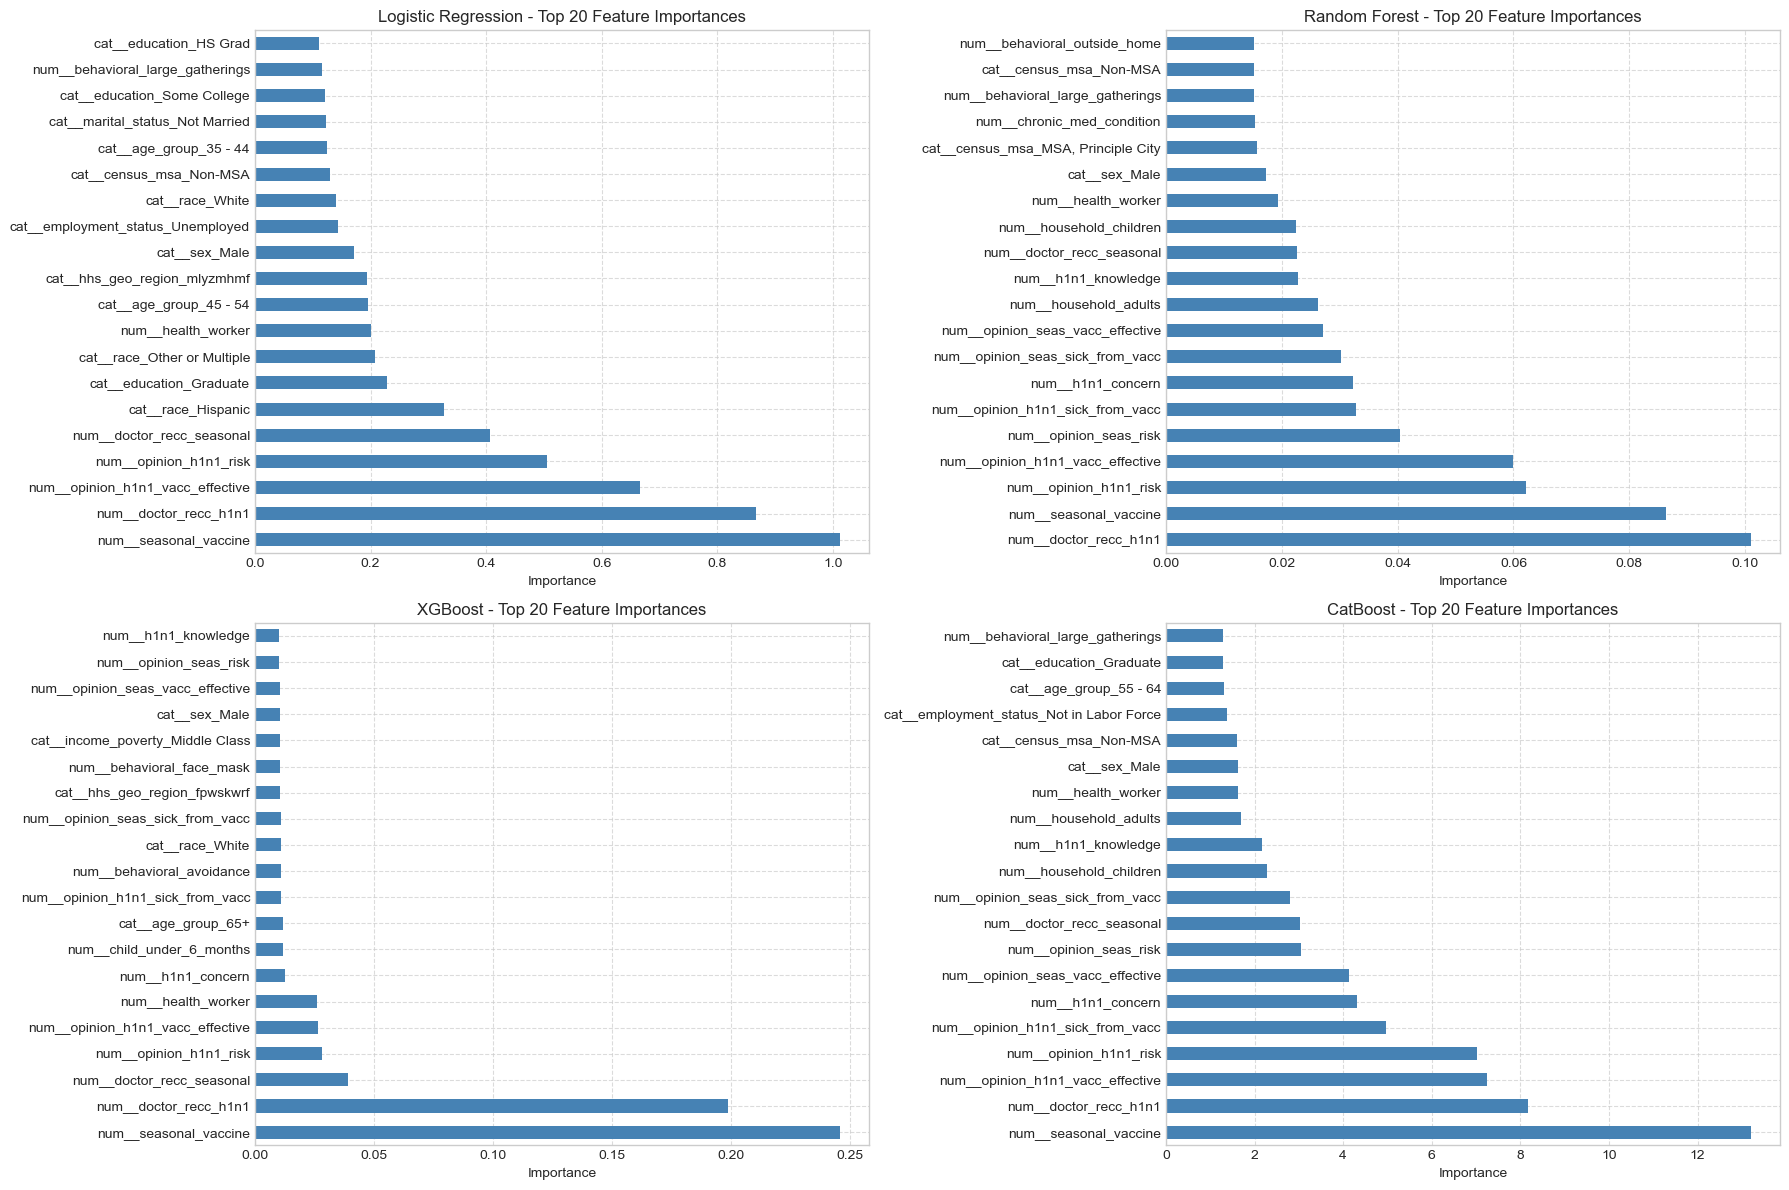

In [ ]:
# PIPELINE-BASED MODEL TRAINING & EVALUATION

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,             
        eval_metric='Logloss'
    )
}


# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models
for name, clf in models.items():

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)

    # Probabilities
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:, 1]
        y_test_prob  = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred

    # Compute metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)

    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })

    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))

    # Feature importances
    final_model = pipeline.named_steps['model']
    try:
        # CatBoost
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), 
                                    index=pipeline.named_steps['preprocess'].get_feature_names_out())
            importances = importances.sort_values(ascending=False).head(20)

        # Tree-based models
        elif hasattr(final_model, 'feature_importances_'):
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                            .sort_values(ascending=False).head(20)

        # Linear models
        elif hasattr(final_model, 'coef_'):
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            coef = np.abs(final_model.coef_).ravel()
            importances = pd.Series(coef, index=feature_names).sort_values(ascending=False).head(20)

        else:
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            importances = pd.Series([0]*len(feature_names), index=feature_names)

    except:
        feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
        importances = pd.Series([0]*len(feature_names), index=feature_names)

    feature_importances[name] = importances


# Display metrics
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Feature importance plots
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## DEALING WITH CLASS IMBALANCE

### 1. USING CLASS WEIGHTS

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.796667,0.790341,0.848586,0.842821,0.796667,0.790341,0.810815,0.804926,0.873921,0.865795
1,Random Forest,1.000000,0.853051,1.000000,0.843572,1.000000,0.853051,1.000000,0.838742,1.000000,0.862393
2,CatBoost,0.911955,0.851928,0.909674,0.842751,0.911955,0.851928,0.908100,0.844336,0.950298,0.871327
3,XGBoost,0.915746,0.818794,0.931048,0.838506,0.915746,0.818794,0.919348,0.825942,0.978395,0.855845


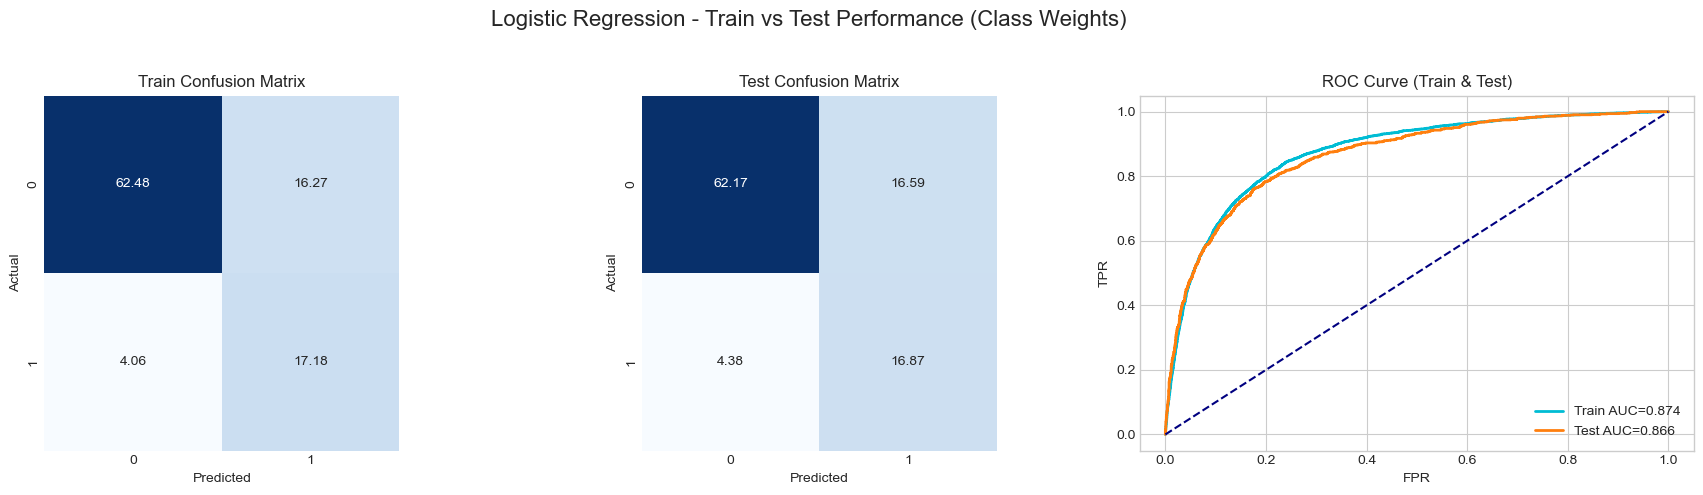

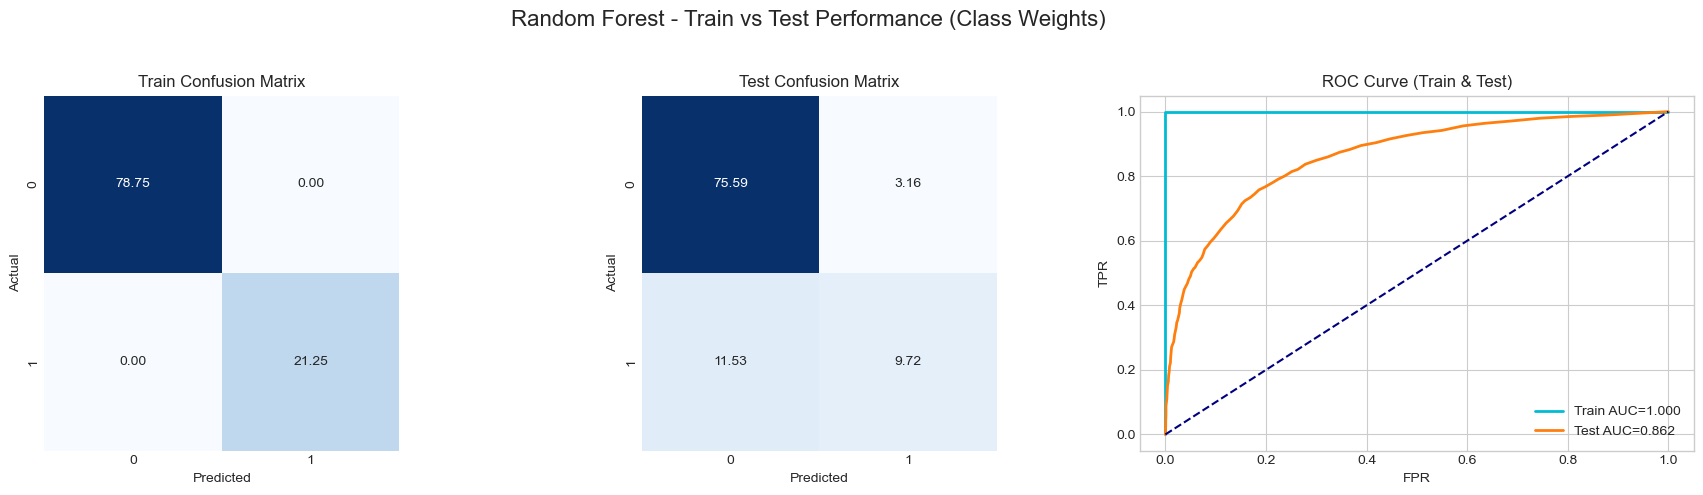

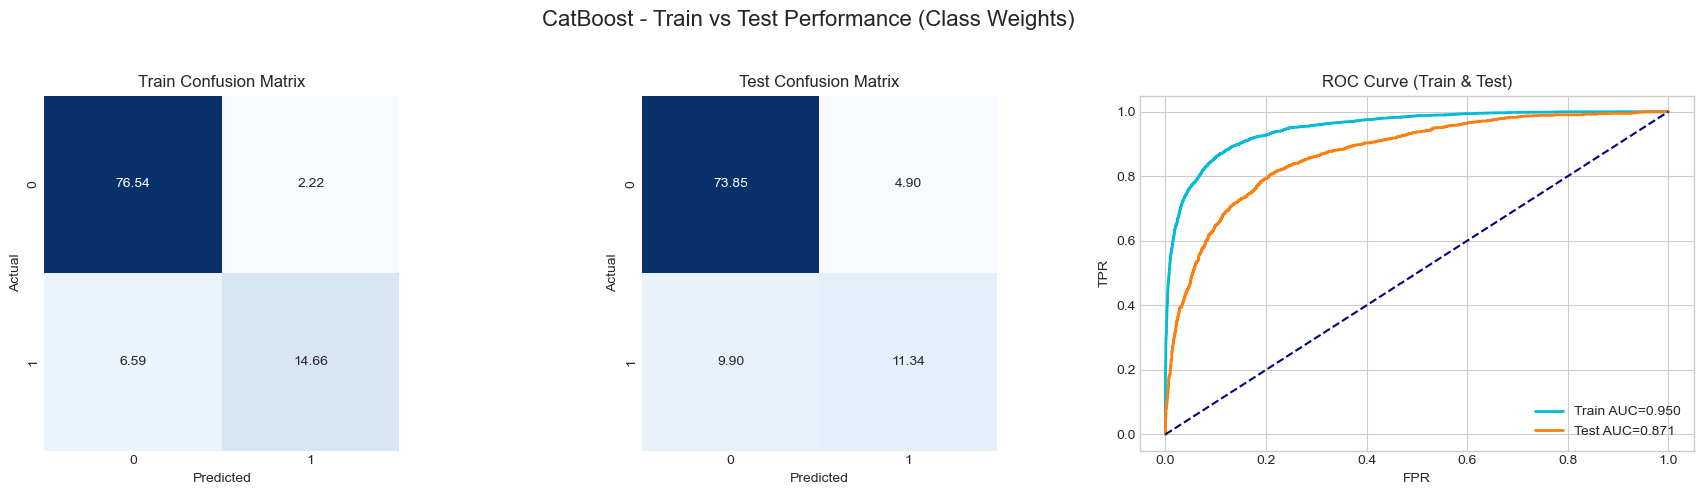

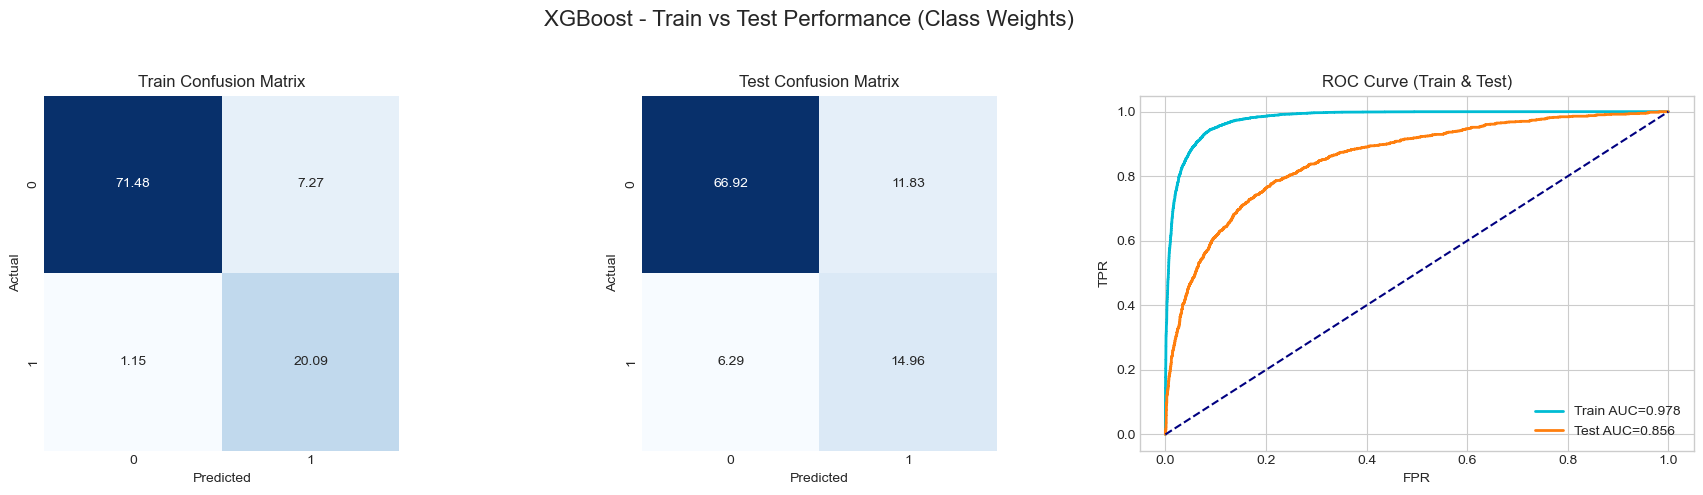

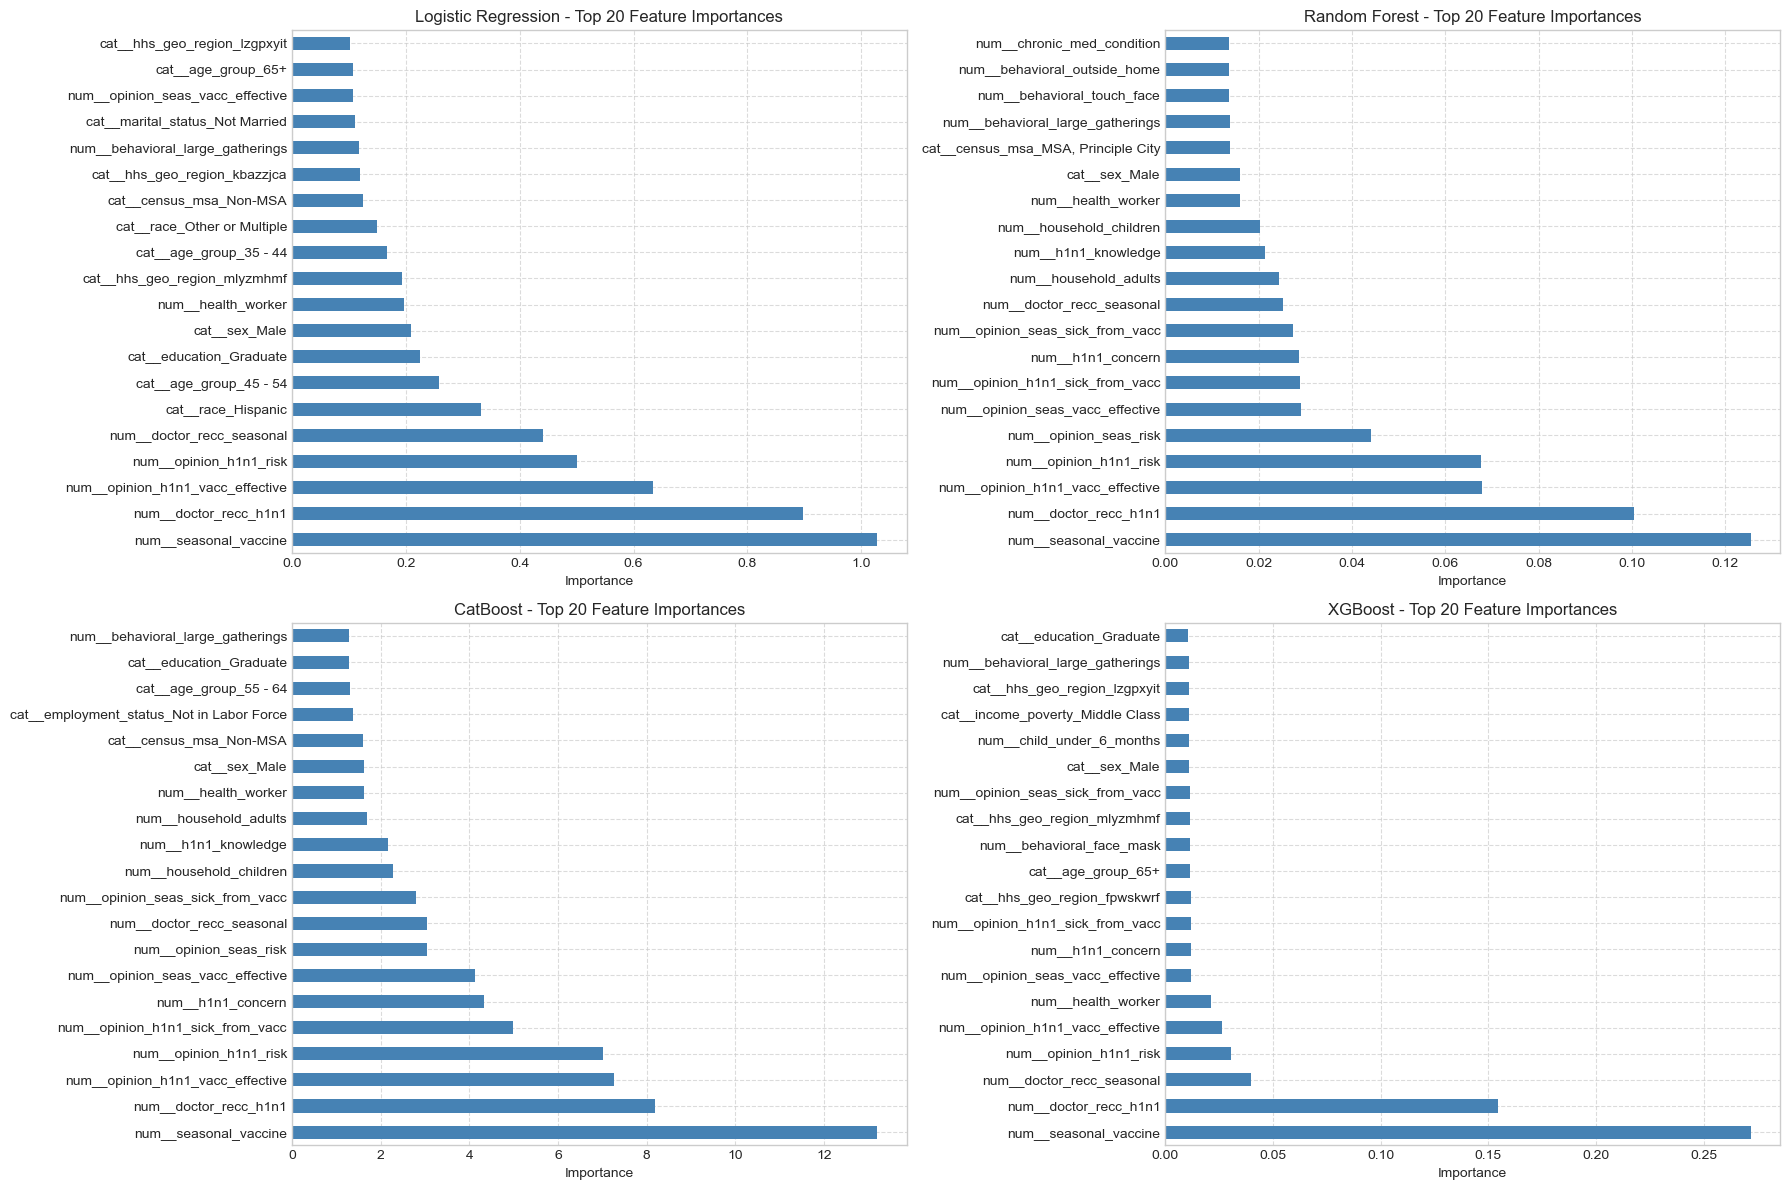

In [ ]:
# Compute XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define models with class weighting
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,
        eval_metric='Logloss'
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models and compute metrics
for name, clf in models.items():
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (Class Weights)", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. USING SMOTE

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.796527,0.795021,0.846439,0.843015,0.796527,0.795021,0.810406,0.808703,0.872586,0.864536
1,Random Forest,1.000000,0.854549,1.000000,0.844890,1.000000,0.854549,1.000000,0.844671,1.000000,0.863164
2,CatBoost,0.914857,0.851554,0.912548,0.842219,0.914857,0.851554,0.911700,0.843740,0.955568,0.870798
3,XGBoost,0.922112,0.850056,0.920175,0.841258,0.922112,0.850056,0.919769,0.843305,0.962787,0.861747


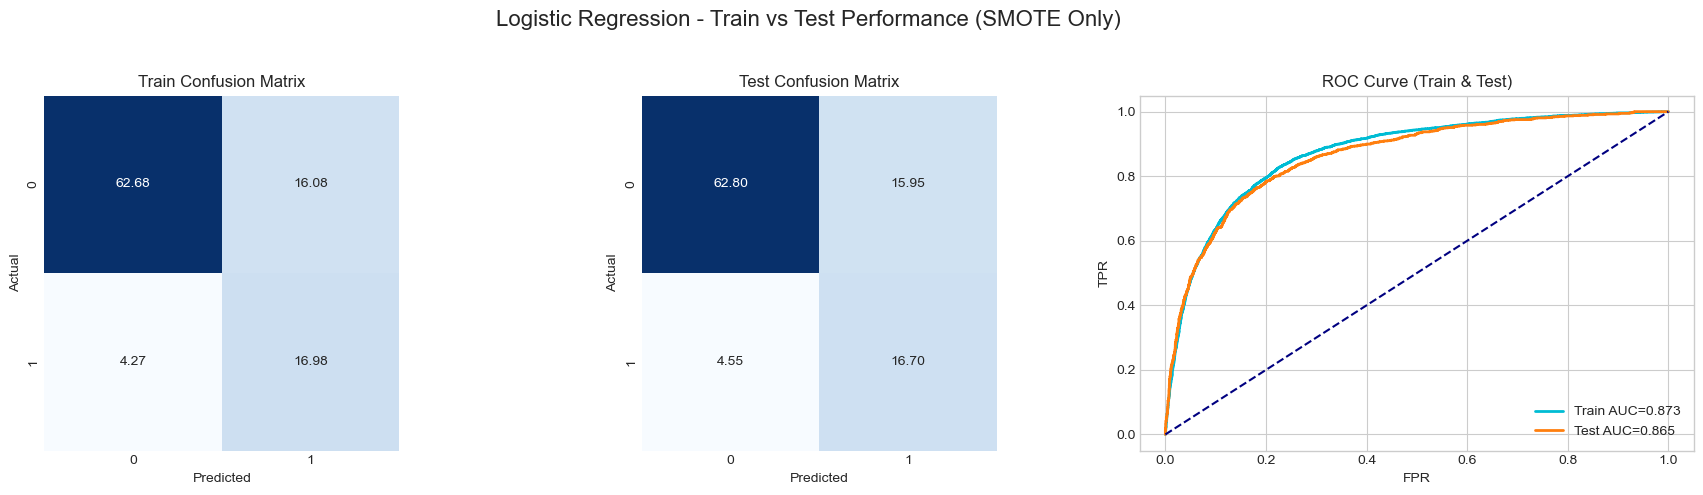

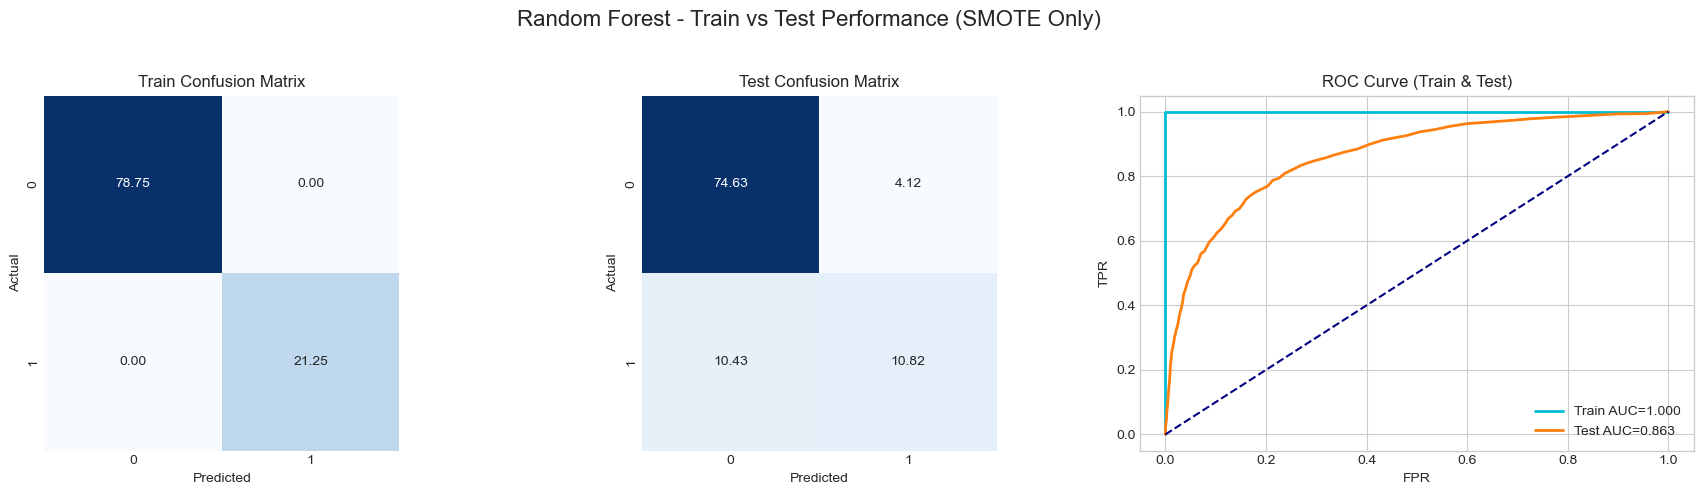

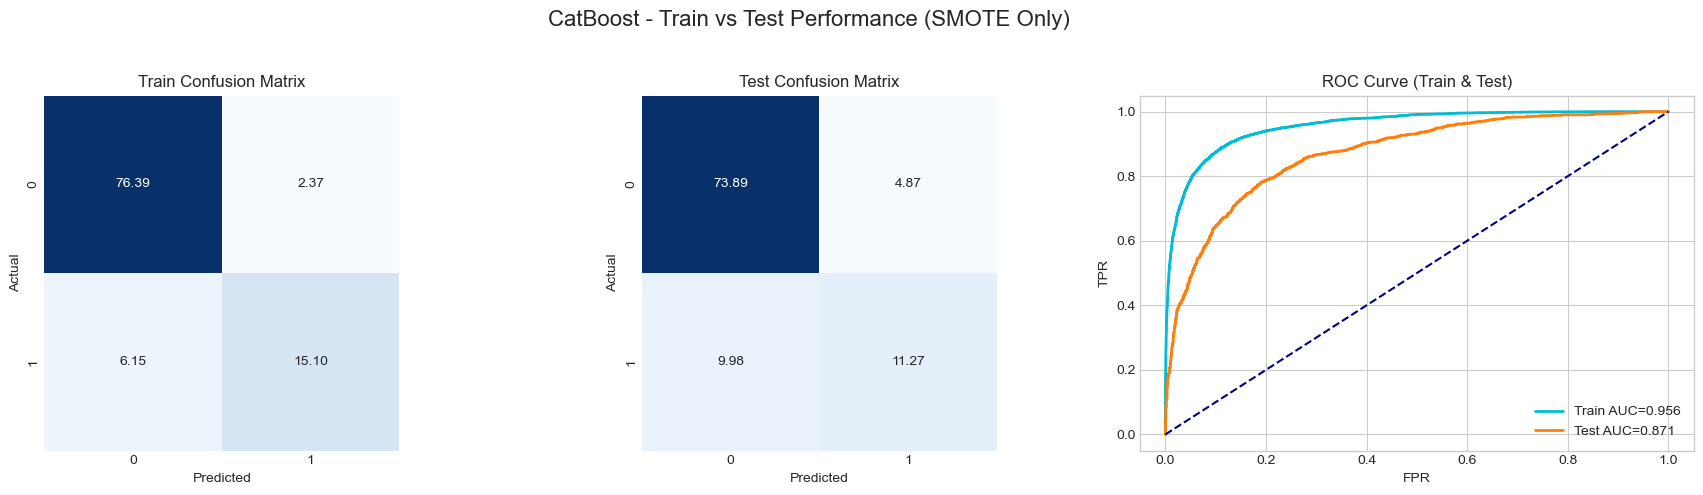

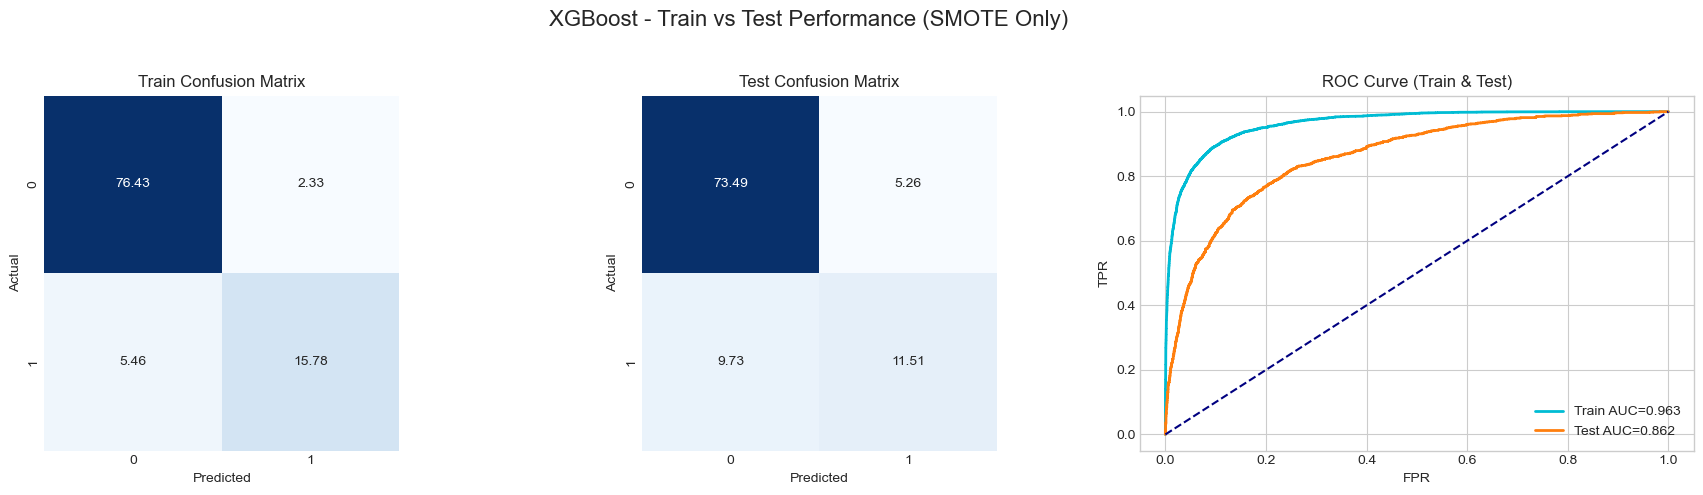

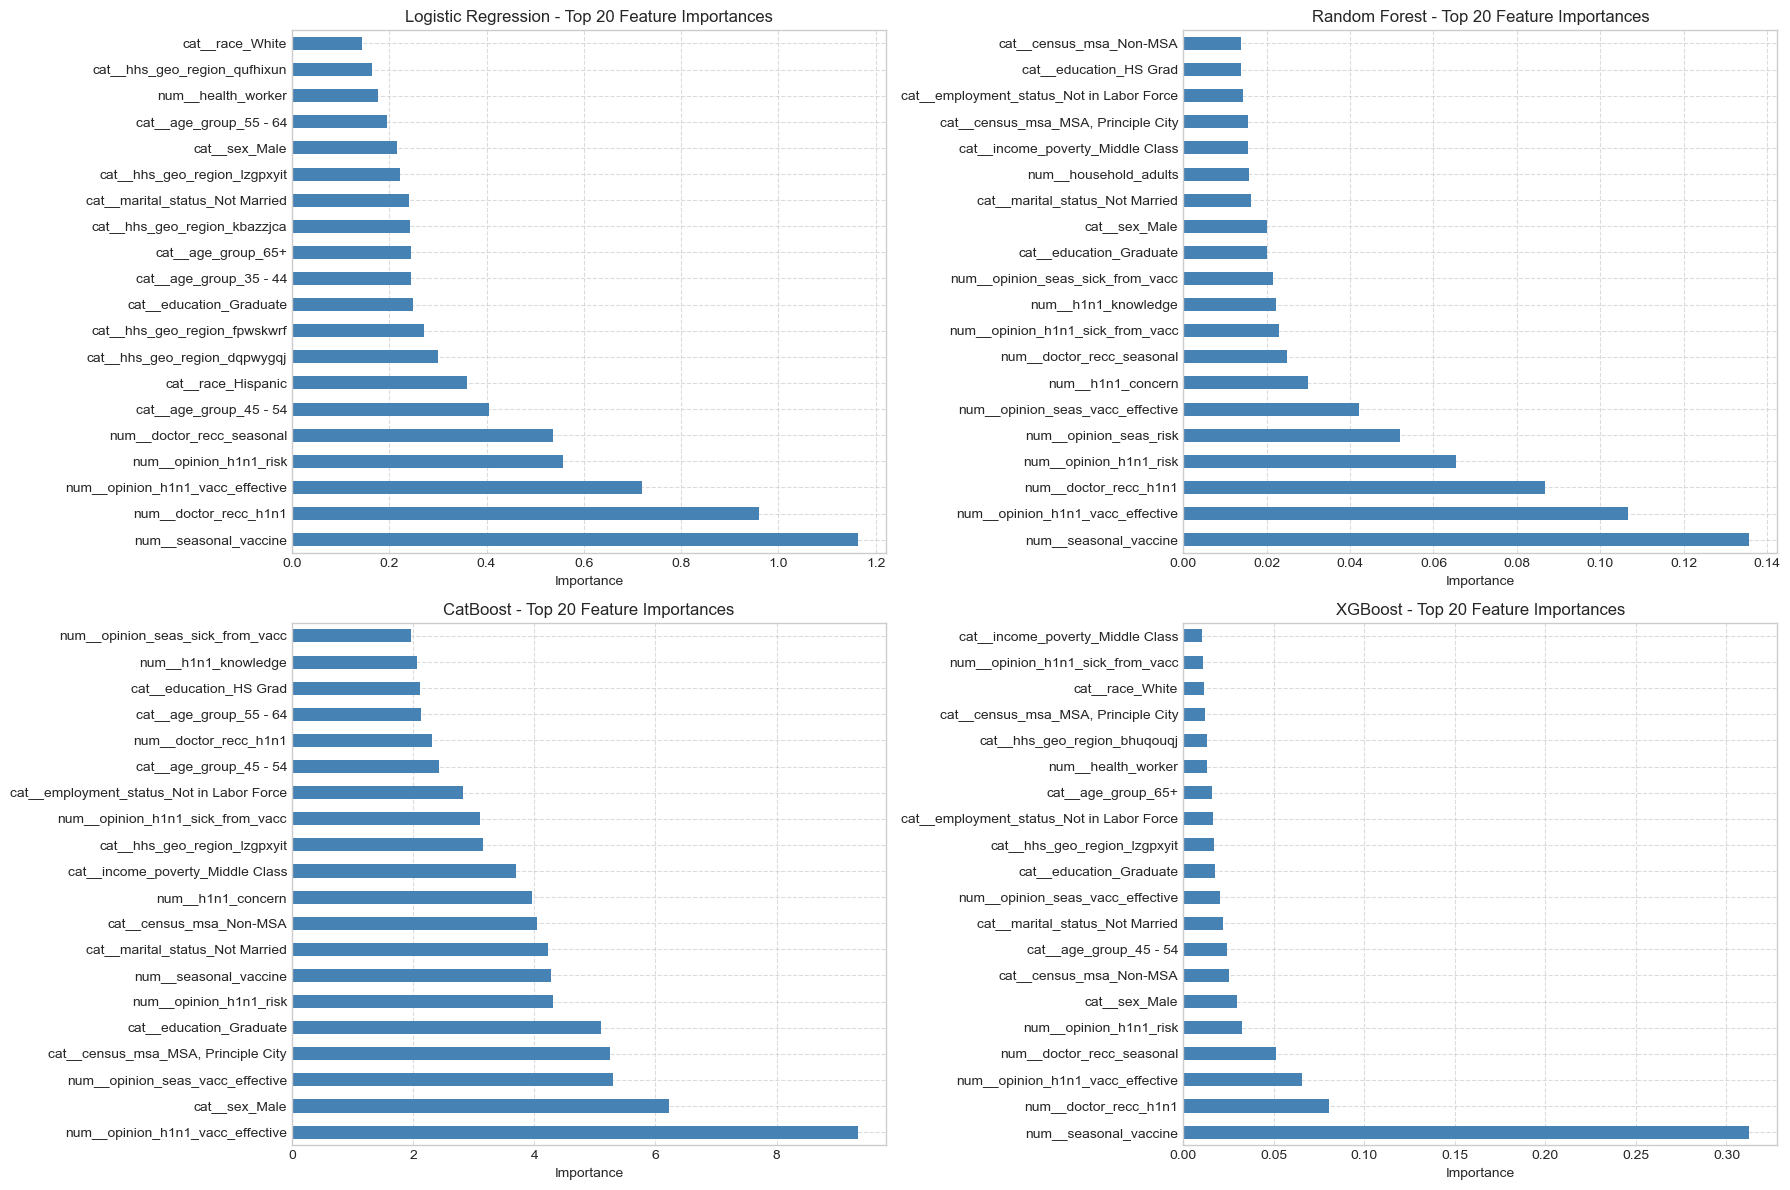

In [7]:
# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,
        eval_metric='Logloss'
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models with SMOTE and compute metrics
for name, clf in models.items():
    
    # Imbalanced pipeline with SMOTE
    pipeline = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    # get feature names from pipeline
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (SMOTE Only)", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## HYPERPARAMETER TUNING

[I 2025-11-26 22:12:44,605] A new study created in memory with name: no-name-2049952d-c1f3-4bcf-b4dc-cbdb5453c43e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-26 22:12:51,814] Trial 0 finished with value: 0.6268656716417911 and parameters: {'iterations': 250, 'depth': 8, 'learning_rate': 0.10725232606905798, 'l2_leaf_reg': 5, 'bagging_temperature': 0.9390411274361592}. Best is trial 0 with value: 0.6268656716417911.
[I 2025-11-26 22:12:53,040] Trial 1 finished with value: 0.6124469589816125 and parameters: {'iterations': 50, 'depth': 2, 'learning_rate': 0.17540210516128568, 'l2_leaf_reg': 1, 'bagging_temperature': 0.8681787748706309}. Best is trial 0 with value: 0.6268656716417911.
[I 2025-11-26 22:12:58,240] Trial 2 finished with value: 0.6221511395441823 and parameters: {'iterations': 150, 'depth': 8, 'learning_rate': 0.24538375231117415, 'l2_leaf_reg': 5, 'bagging_temperature': 0.36146729686256207}. Best is trial 0 with value: 0.6268656716417911.
[I 2025-11-26 22:13:03,895] Trial 3 finished with value: 0.64 and parameters: {'iterations': 200, 'depth': 8, 'learning_rate': 0.15079230261975773, 'l2_leaf_reg': 5, 'bagging_temperatu

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,RandomizedSearchCV,0.868798,0.814676,0.897958,0.846221,0.868798,0.814676,0.876140,0.824641,0.945737,0.873728
1,Optuna,0.912423,0.826657,0.929019,0.846592,0.912423,0.826657,0.916313,0.833681,0.976617,0.868060
2,GridSearchCV,0.870015,0.819918,0.898270,0.849719,0.870015,0.819918,0.877178,0.829343,0.948016,0.874757


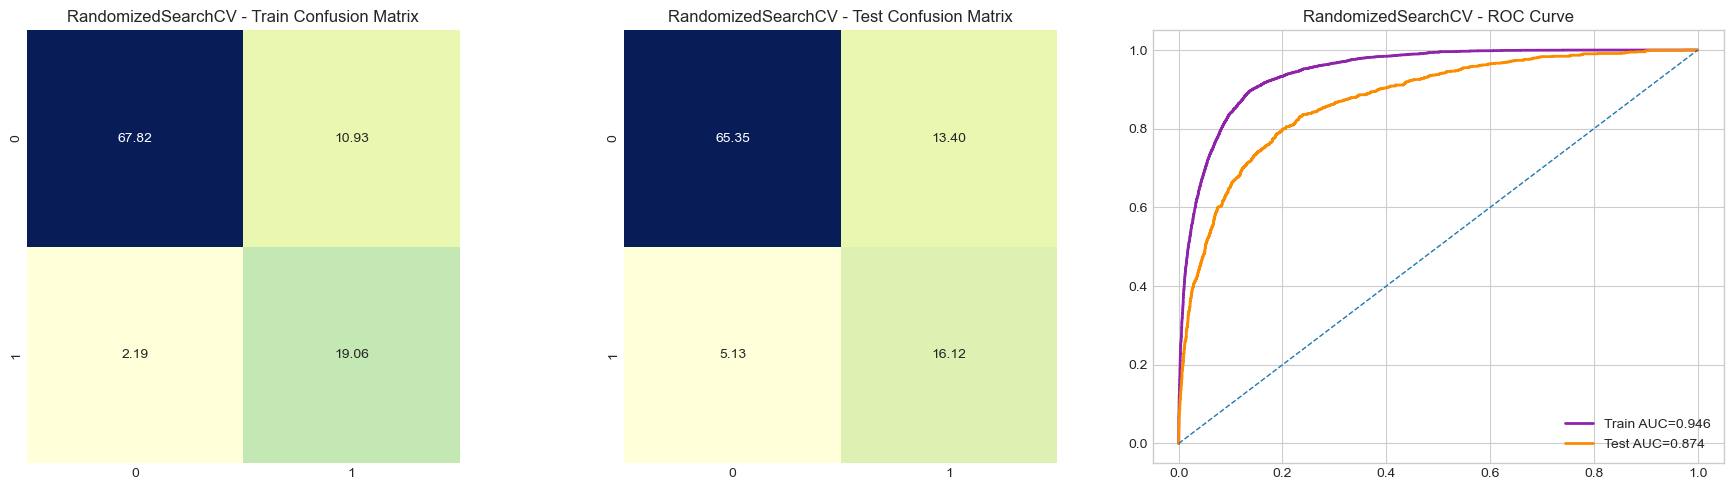

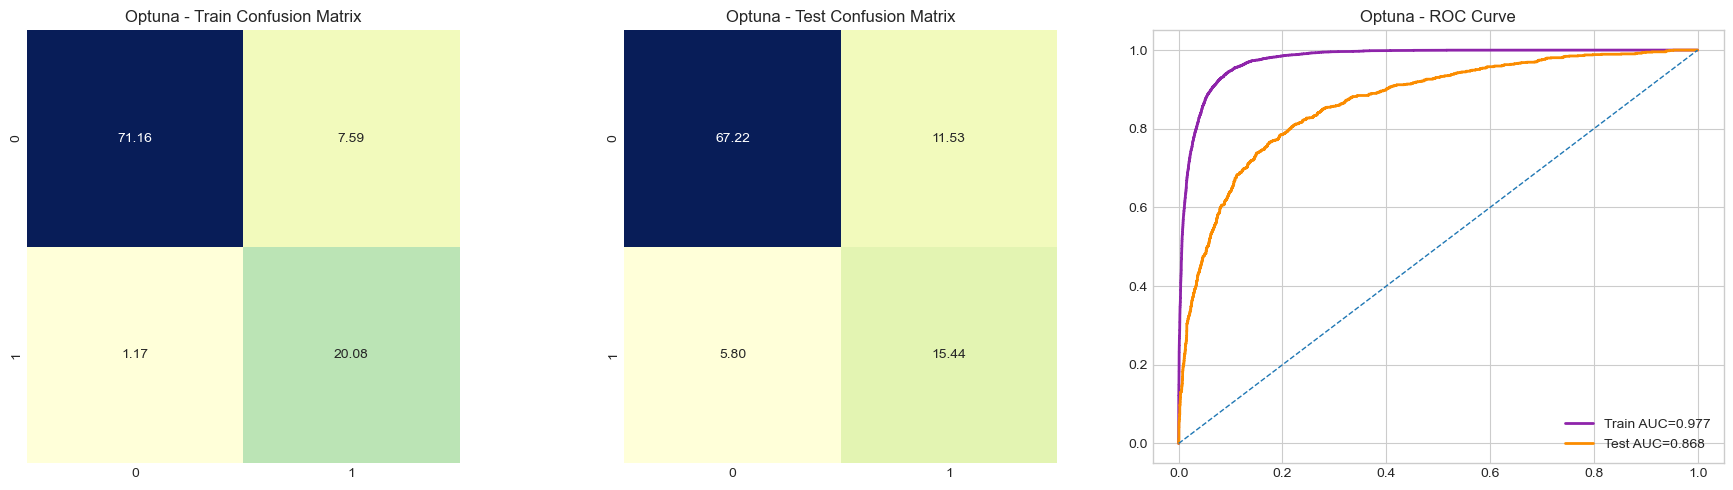

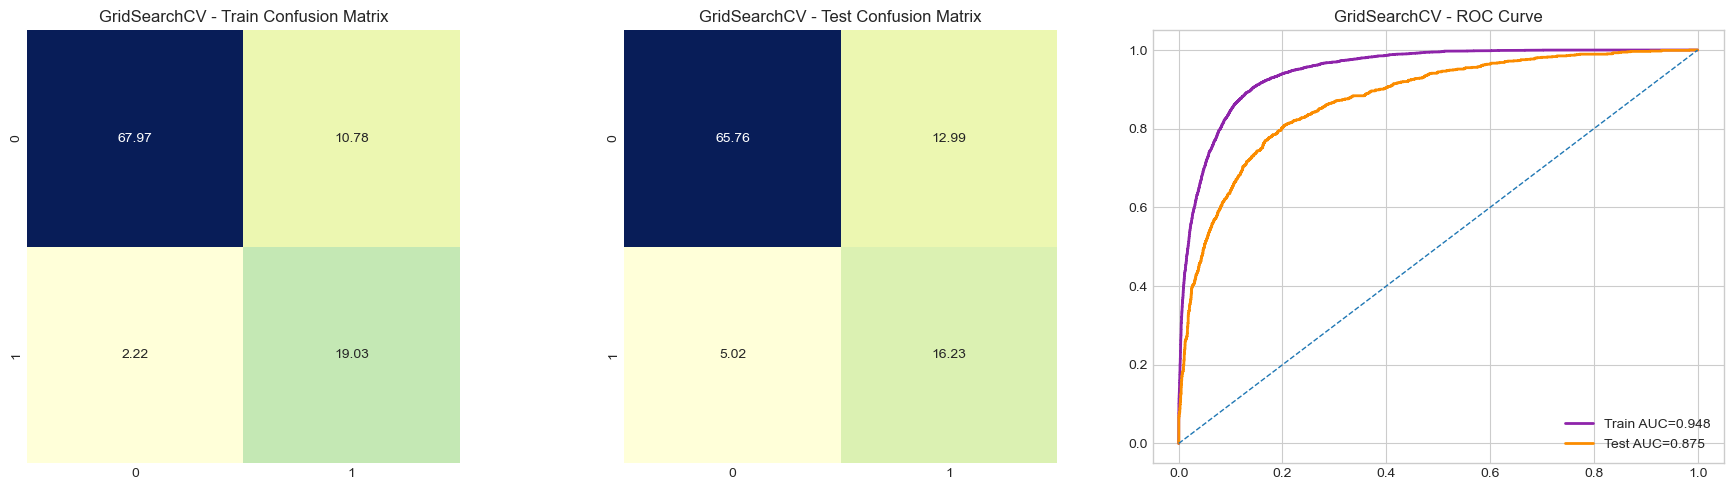

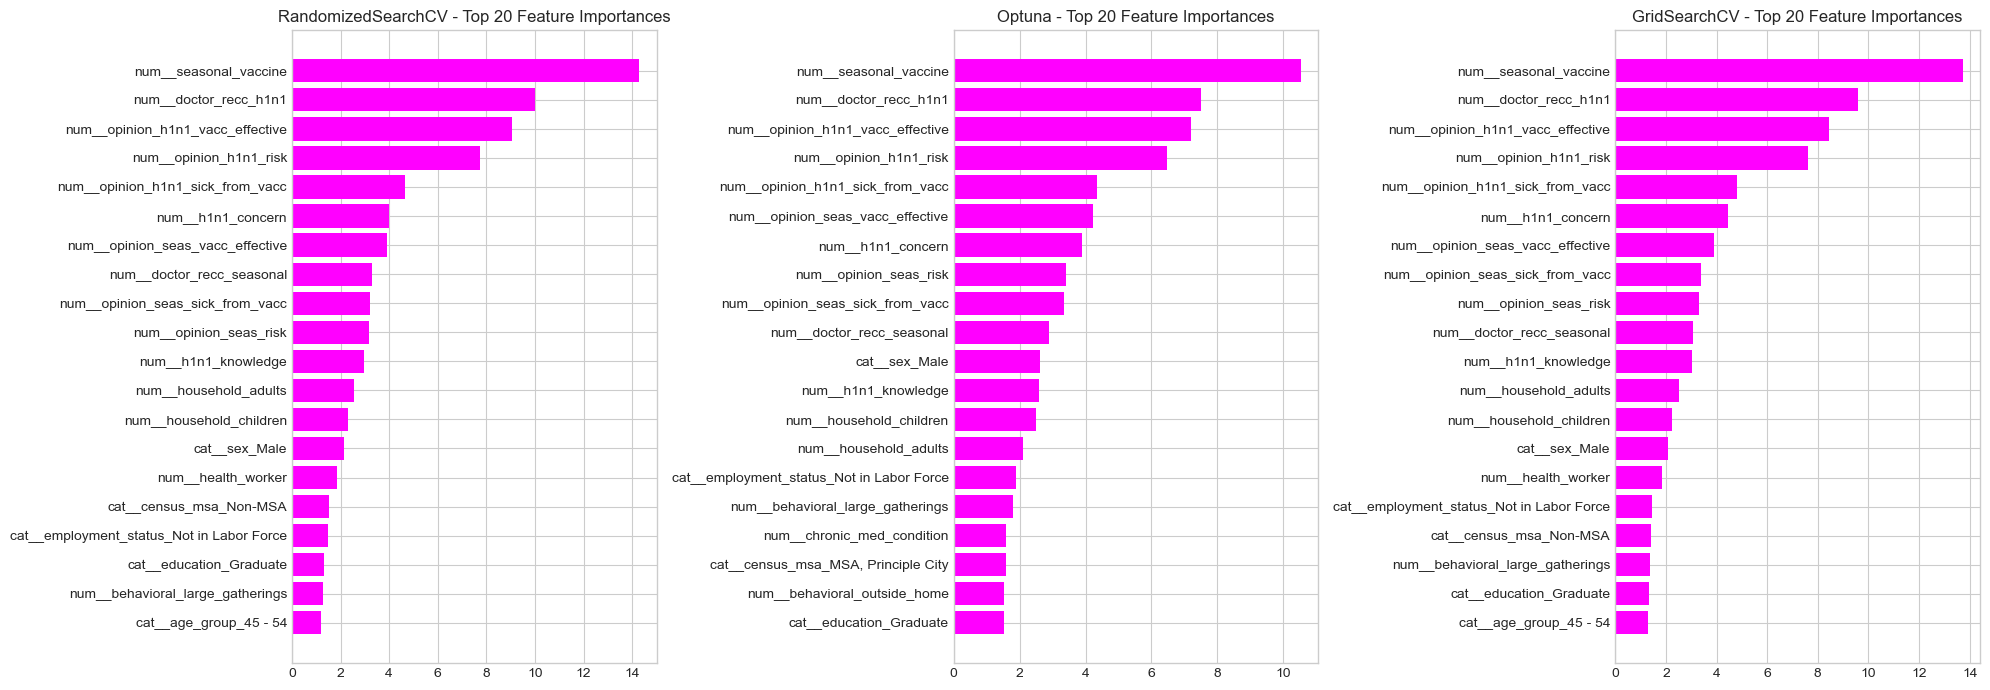

In [ ]:
# Class weights
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weights = [1, scale_pos_weight] 

# Helpers — Metrics, ROC, Confusion Matrix
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_val = auc(fpr, tpr)

    metrics = {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
        "roc_auc": roc_val
    }
    return metrics, cm, (fpr, tpr, roc_val)


# Evaluation function
def evaluate_model(pipeline, X_train, y_train, X_test, y_test, name):
    y_tr_pred = pipeline.predict(X_train)
    y_te_pred = pipeline.predict(X_test)
    y_tr_prob = pipeline.predict_proba(X_train)[:, 1]
    y_te_prob = pipeline.predict_proba(X_test)[:, 1]

    tr_metrics, tr_cm, tr_roc = compute_metrics(y_train, y_tr_pred, y_tr_prob)
    te_metrics, te_cm, te_roc = compute_metrics(y_test, y_te_pred, y_te_prob)

    metrics = {
        'Model': name,
        'Train Accuracy': tr_metrics['accuracy'],
        'Test Accuracy': te_metrics['accuracy'],
        'Train Precision': tr_metrics['precision'],
        'Test Precision': te_metrics['precision'],
        'Train Recall': tr_metrics['recall'],
        'Test Recall': te_metrics['recall'],
        'Train F1': tr_metrics['f1'],
        'Test F1': te_metrics['f1'],
        'Train ROC-AUC': tr_metrics['roc_auc'],
        'Test ROC-AUC': te_metrics['roc_auc']
    }

    model = pipeline.named_steps['model']

    # Feature importances
    try:
        feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
        importances = model.get_feature_importance()
        fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
    except:
        fi = pd.Series([0]*pipeline.named_steps['preprocess'].transform(X_train).shape[1])

    return metrics, tr_cm, te_cm, tr_roc, te_roc, fi


# Base pipeline
base_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(
        random_state=42,
        silent=True,
        eval_metric='Logloss',
        class_weights=class_weights
    ))
])

# Randomized search parameters
f1_scorer = make_scorer(f1_score, pos_label=1)

param_dist = {
    'model__iterations': [50, 150, 200, 250],
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__l2_leaf_reg': [1, 3, 5, 7],
    'model__bagging_temperature': [0.0, 0.3, 0.7]
}

rand_search = RandomizedSearchCV(
    base_pipe, param_distributions=param_dist, n_iter=30,
    cv=5, scoring=f1_scorer, random_state=42
)
rand_search.fit(X_train, y_train)
best_random = rand_search.best_params_

# Optuna tuning
def optuna_objective(trial):
    params = {
        'model__iterations': trial.suggest_categorical('iterations', [50, 150, 200, 250]),
        'model__depth': trial.suggest_categorical('depth', [2, 5, 8]),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'model__l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'model__bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0)
    }

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', CatBoostClassifier(
            random_state=42,
            silent=True,
            eval_metric='Logloss',
            class_weights=class_weights
        ))
    ])
    pipe.set_params(**params)
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

best_optuna = {f"model__{k}": v for k, v in study.best_params.items()}

# Grid search parameters
grid_params = {
    'model__iterations': [50, 100, 150, 200, 250],
    'model__depth': [2, 5, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__l2_leaf_reg': [3, 5, 7],
    'model__bagging_temperature': [0.0, 0.3]
}

grid_search = GridSearchCV(base_pipe, param_grid=grid_params, cv=5, scoring=f1_scorer)
grid_search.fit(X_train, y_train)
best_grid = grid_search.best_params_

# BUILD FINAL MODELS
def build_pipeline(best_params):
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', CatBoostClassifier(
            random_state=42,
            silent=True,
            eval_metric='Logloss',
            class_weights=class_weights
        ))
    ])
    pipe.set_params(**best_params)
    pipe.fit(X_train, y_train)
    return pipe

models = {
    'RandomizedSearchCV': build_pipeline(best_random),
    'Optuna': build_pipeline(best_optuna),
    'GridSearchCV': build_pipeline(best_grid)
}

# Evaluation
results = {
    name: evaluate_model(model, X_train, y_train, X_test, y_test, name)
    for name, model in models.items()
}

metrics_df = pd.DataFrame([res[0] for res in results.values()])
display(metrics_df)

# Plots
def plot_separate_figures(results_dict):
    for name, res in results_dict.items():
        train_cm = res[1] / res[1].sum() * 100
        test_cm = res[2] / res[2].sum() * 100
        fpr_tr, tpr_tr, auc_tr = res[3]
        fpr_te, tpr_te, auc_te = res[4]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.heatmap(train_cm, annot=True, fmt='.2f', cmap='YlGnBu',
                    cbar=False, square=True, ax=axes[0])
        axes[0].set_title(f'{name} - Train Confusion Matrix')

        sns.heatmap(test_cm, annot=True, fmt='.2f', cmap='YlGnBu',
                    cbar=False, square=True, ax=axes[1])
        axes[1].set_title(f'{name} - Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')

        axes[2].plot(fpr_tr, tpr_tr, lw=2, label=f'Train AUC={auc_tr:.3f}', color='#8e24aa')
        axes[2].plot(fpr_te, tpr_te, lw=2, label=f'Test AUC={auc_te:.3f}', color='#fb8c00')
        axes[2].plot([0, 1], [0, 1], '--', linewidth=1)
        axes[2].set_title(f'{name} - ROC Curve')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

plot_separate_figures(results)

# Feature importance plots
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, name in enumerate(['RandomizedSearchCV', 'Optuna', 'GridSearchCV']):
    fi = results[name][5].sort_values()
    axes[i].barh(fi.index, fi.values, color='magenta')
    axes[i].set_title(f'{name} - Top 20 Feature Importances')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Pick best model
best_model = models['Optuna']

# Save the pipeline
joblib.dump(best_model, 'h1n1_pipeline.pkl')

# Load it
loaded_model = joblib.load('h1n1_pipeline.pkl')

# Use the loaded model
y_pred = loaded_model.predict(X_test)

# Check predictions
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
display(results_df.head(20)) 

,Actual,Predicted
23200,1,0
1928,1,1
24951,0,0
20230,0,0
20207,0,0
14604,0,0
14060,0,1
21375,1,0
19550,0,1
26463,0,0


Seasonal Flu Vaccine

In [12]:
# ------- [PREPROCESSING PIPELINE] -------

# Separate features and target
X = df.drop('seasonal_vaccine', axis=1)
y = df['seasonal_vaccine']

# Identify feature types
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# Fit pipeline
X_processed = preprocessor.fit_transform(X)

# Extract transformed column names
encoded_cat_cols = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
processed_feature_names = num_cols + list(encoded_cat_cols)

# Convert to DataFrame
df_processed = pd.DataFrame(X_processed, columns=processed_feature_names)

# Compute VIF
df_vif = df_processed.copy()
df_vif['intercept'] = 1 

vif_df = pd.DataFrame({
    'feature': df_vif.columns,
    'VIF': [
        variance_inflation_factor(df_vif.values, i)
        for i in range(df_vif.shape[1])
    ]
})

display(vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True))

,feature,VIF
0,intercept,54.736570
1,education_Graduate,4.219814
2,education_Some College,3.302628
3,education_HS Grad,2.862051
4,age_group_65+,2.781643
5,hhs_geo_region_lzgpxyit,2.678255
6,race_White,2.613342
7,hhs_geo_region_fpwskwrf,2.356292
8,hhs_geo_region_qufhixun,2.258511
9,hhs_geo_region_bhuqouqj,2.188096


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.800459,0.797267,0.800641,0.797756,0.800459,0.797267,0.799910,0.796522,0.874424,0.873237
1,Random Forest,1.000000,0.798390,1.000000,0.798312,1.000000,0.798390,1.000000,0.798028,1.000000,0.872244
2,XGBoost,0.899972,0.796144,0.900094,0.796203,0.899972,0.796144,0.899855,0.795645,0.963253,0.874331
3,CatBoost,0.868424,0.809060,0.868509,0.809153,0.868424,0.809060,0.868246,0.808623,0.940613,0.883211


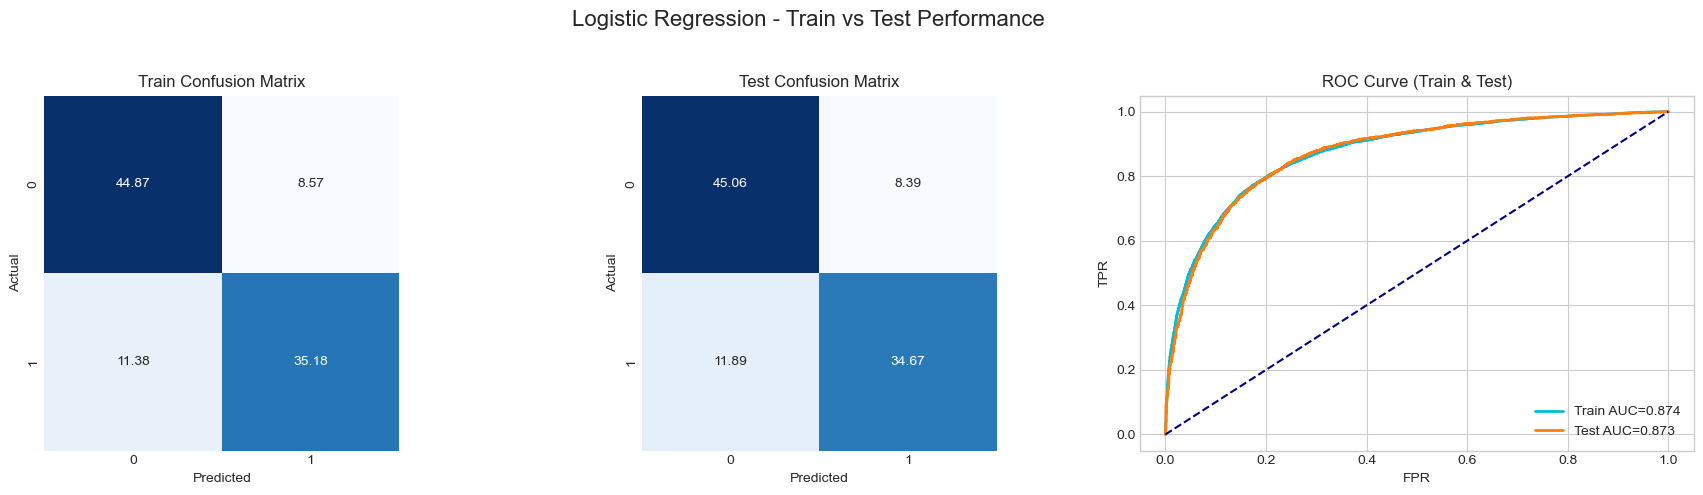

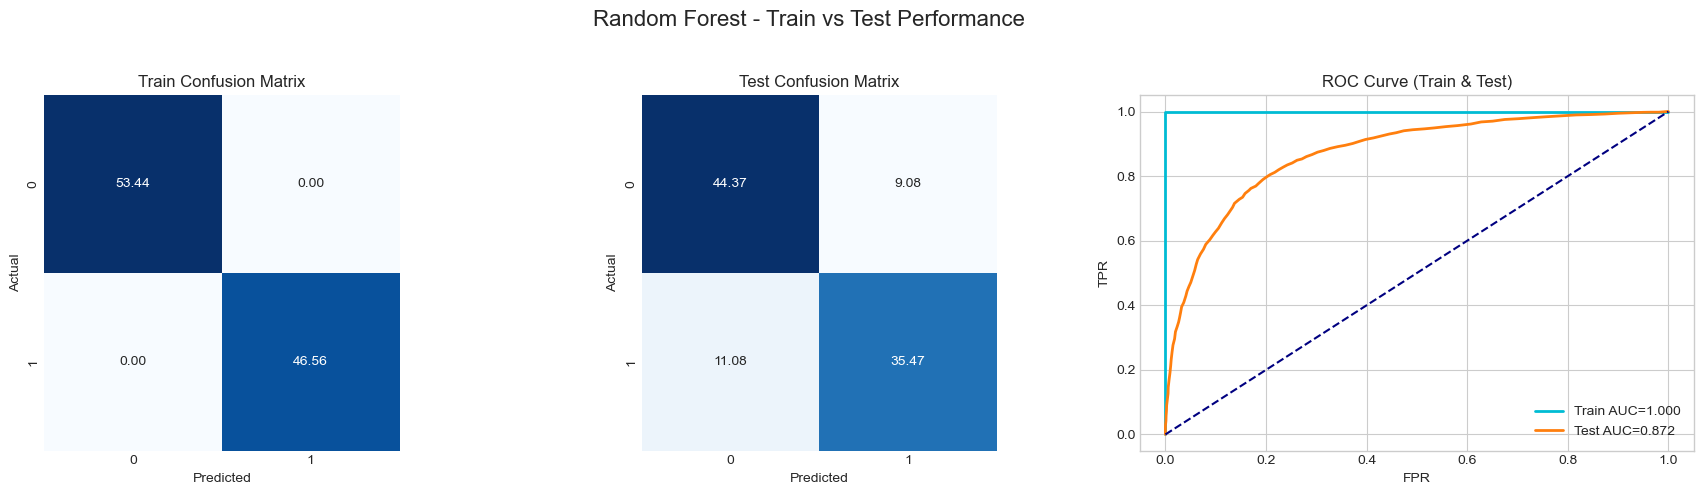

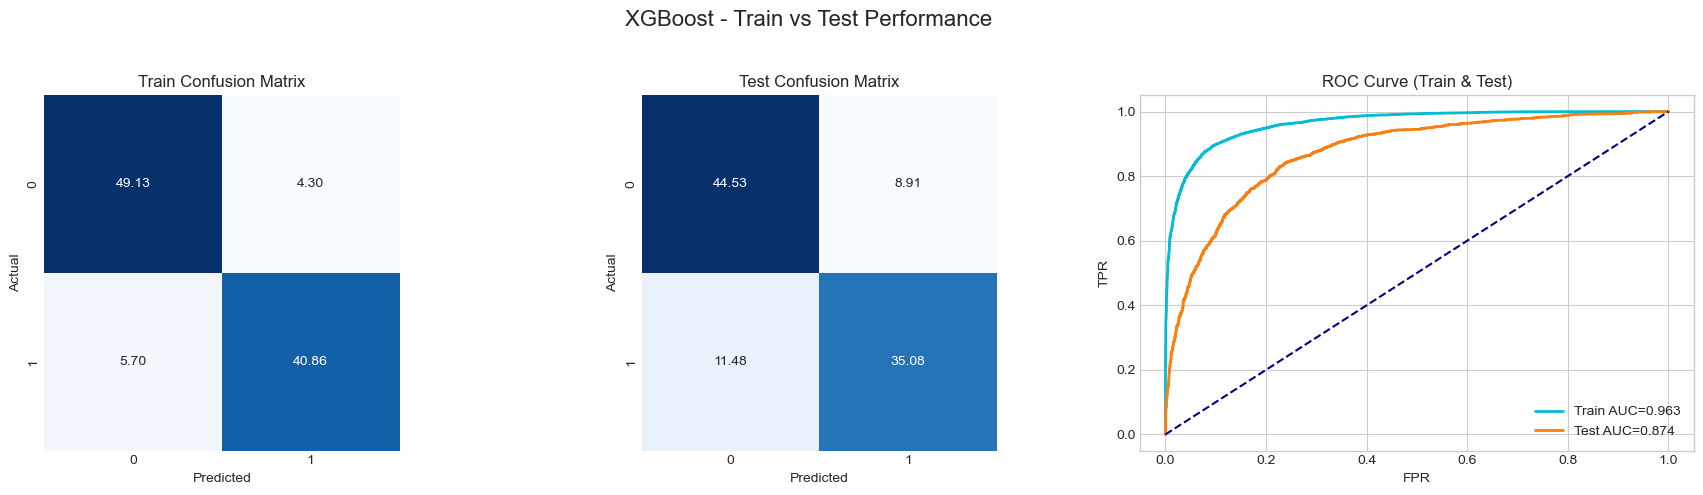

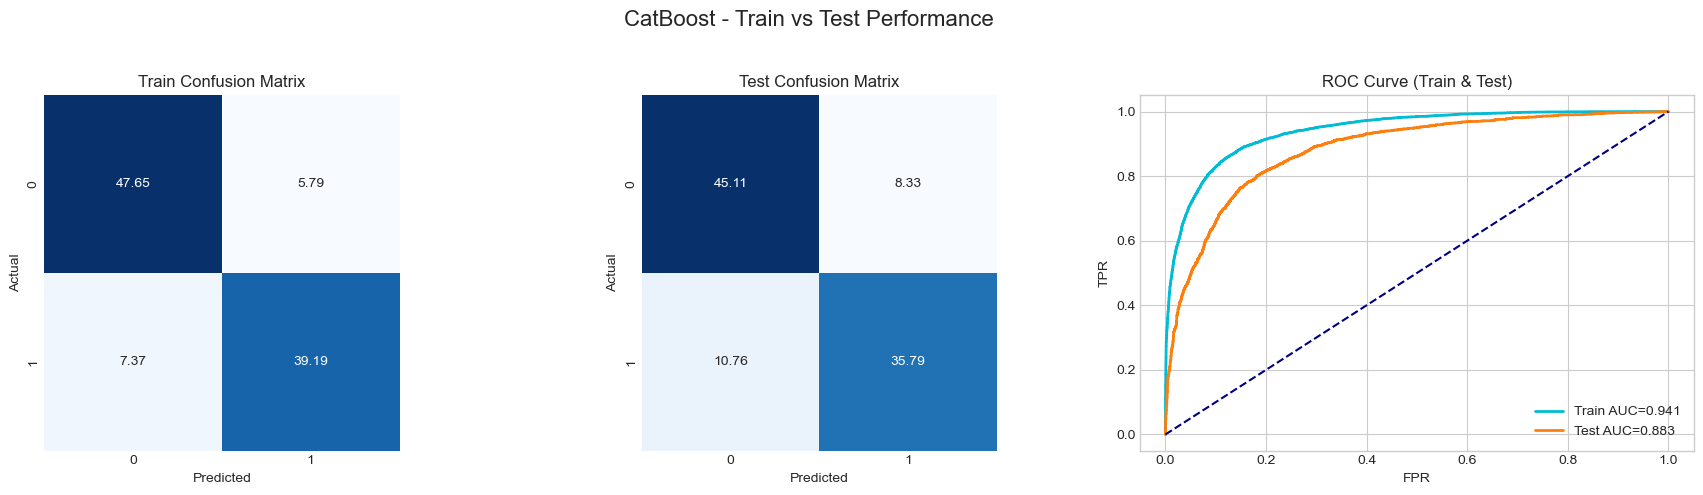

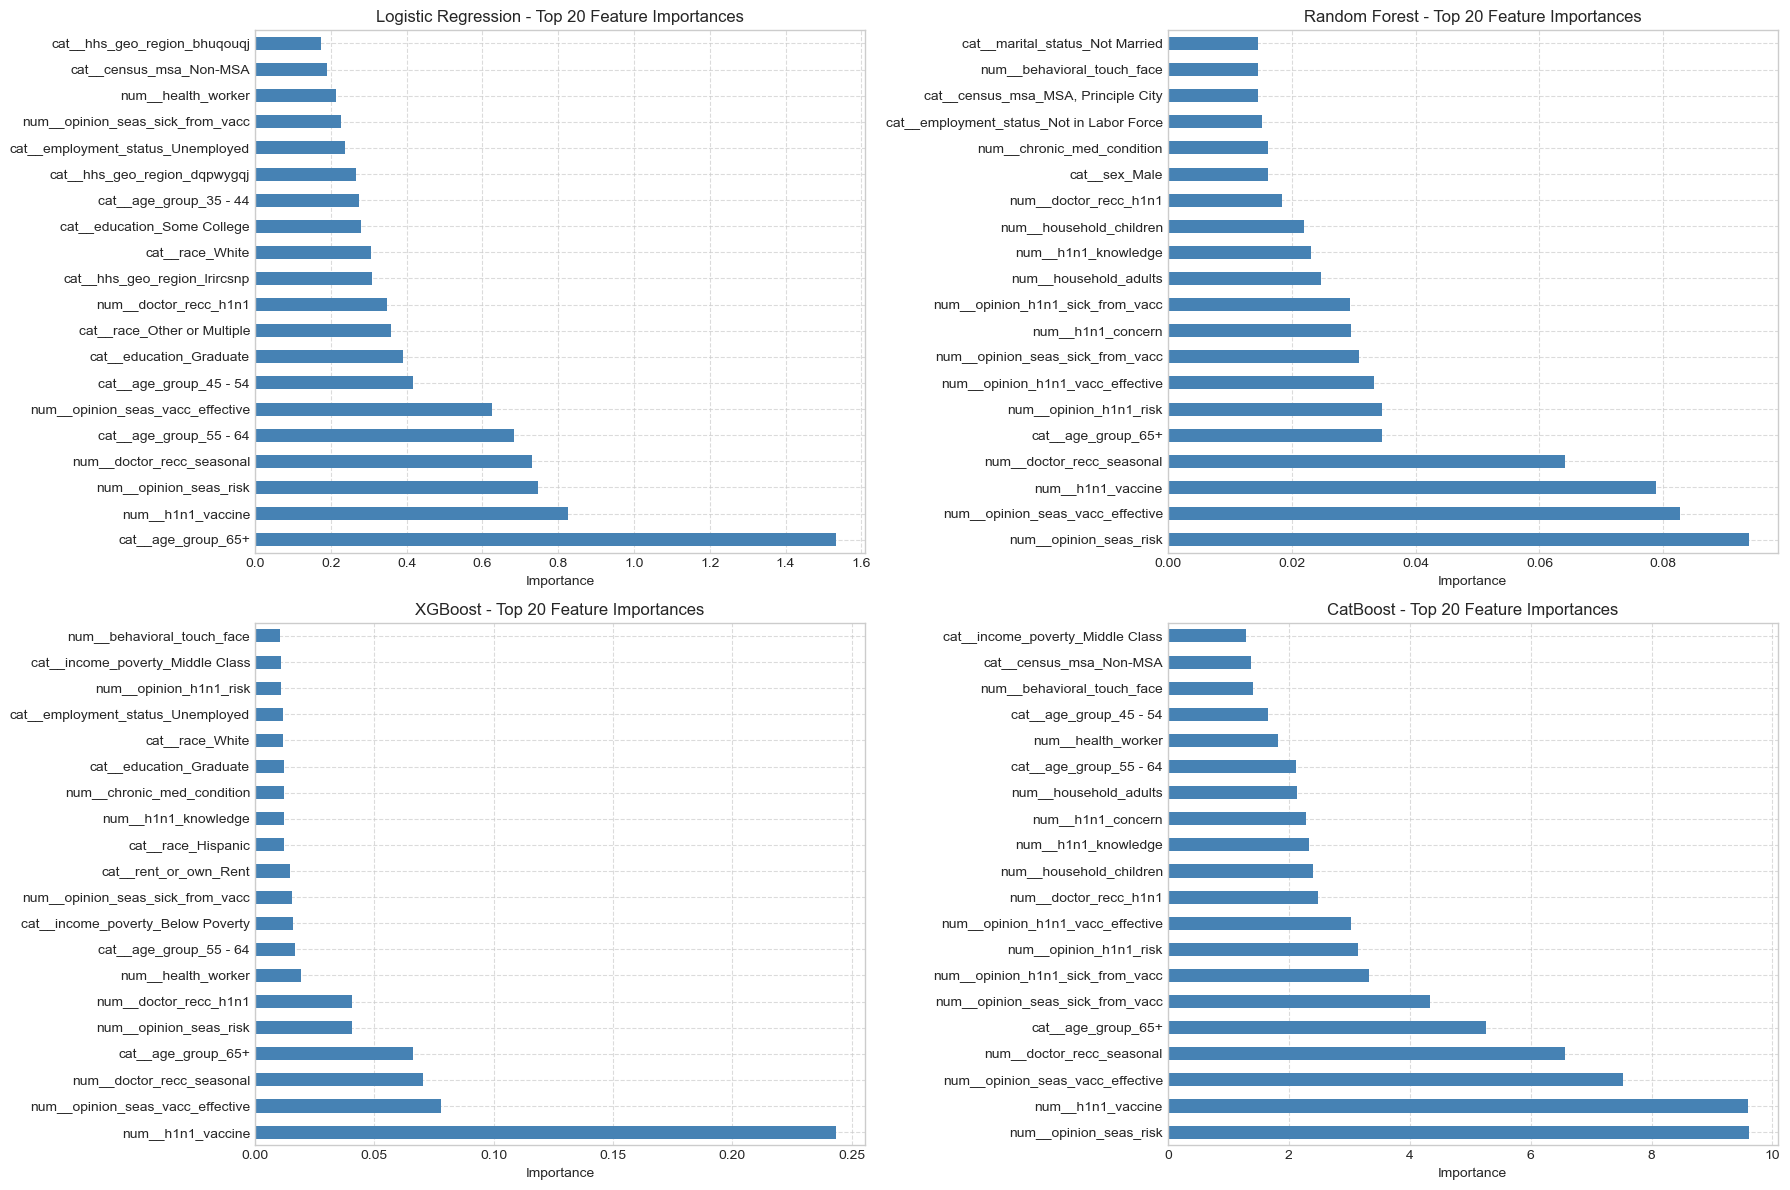

In [13]:
# PIPELINE-BASED MODEL TRAINING & EVALUATION

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,             
        eval_metric='Logloss'
    )
}


# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models
for name, clf in models.items():

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)

    # Probabilities
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:, 1]
        y_test_prob  = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred

    # Compute metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)

    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })

    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))

    # Feature importances
    final_model = pipeline.named_steps['model']
    try:
        # CatBoost
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), 
                                    index=pipeline.named_steps['preprocess'].get_feature_names_out())
            importances = importances.sort_values(ascending=False).head(20)

        # Tree-based models
        elif hasattr(final_model, 'feature_importances_'):
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                            .sort_values(ascending=False).head(20)

        # Linear models
        elif hasattr(final_model, 'coef_'):
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            coef = np.abs(final_model.coef_).ravel()
            importances = pd.Series(coef, index=feature_names).sort_values(ascending=False).head(20)

        else:
            feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
            importances = pd.Series([0]*len(feature_names), index=feature_names)

    except:
        feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
        importances = pd.Series([0]*len(feature_names), index=feature_names)

    feature_importances[name] = importances


# Display metrics
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Feature importance plots
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.799991,0.798390,0.799870,0.798228,0.799991,0.798390,0.799903,0.798218,0.874440,0.873243
1,Random Forest,1.000000,0.797829,1.000000,0.797868,1.000000,0.797829,1.000000,0.797357,1.000000,0.873586
2,CatBoost,0.868424,0.809060,0.868509,0.809153,0.868424,0.809060,0.868246,0.808623,0.940613,0.883211
3,XGBoost,0.897959,0.801385,0.897934,0.801245,0.897959,0.801385,0.897941,0.801268,0.964076,0.873068


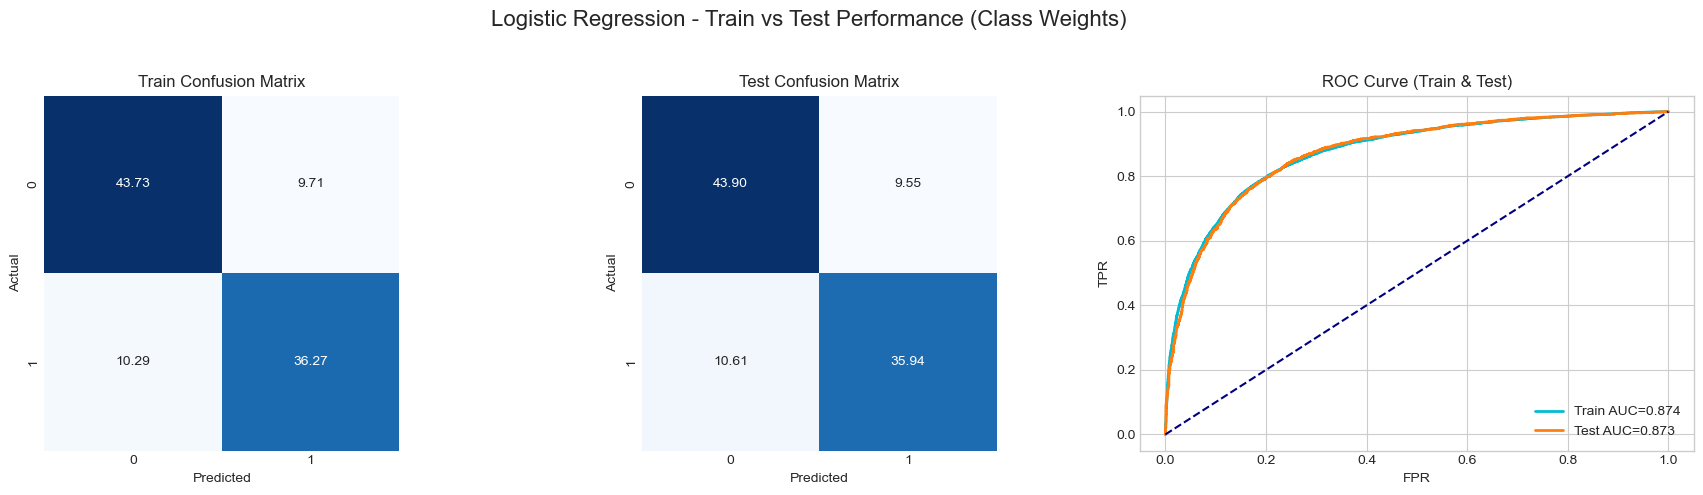

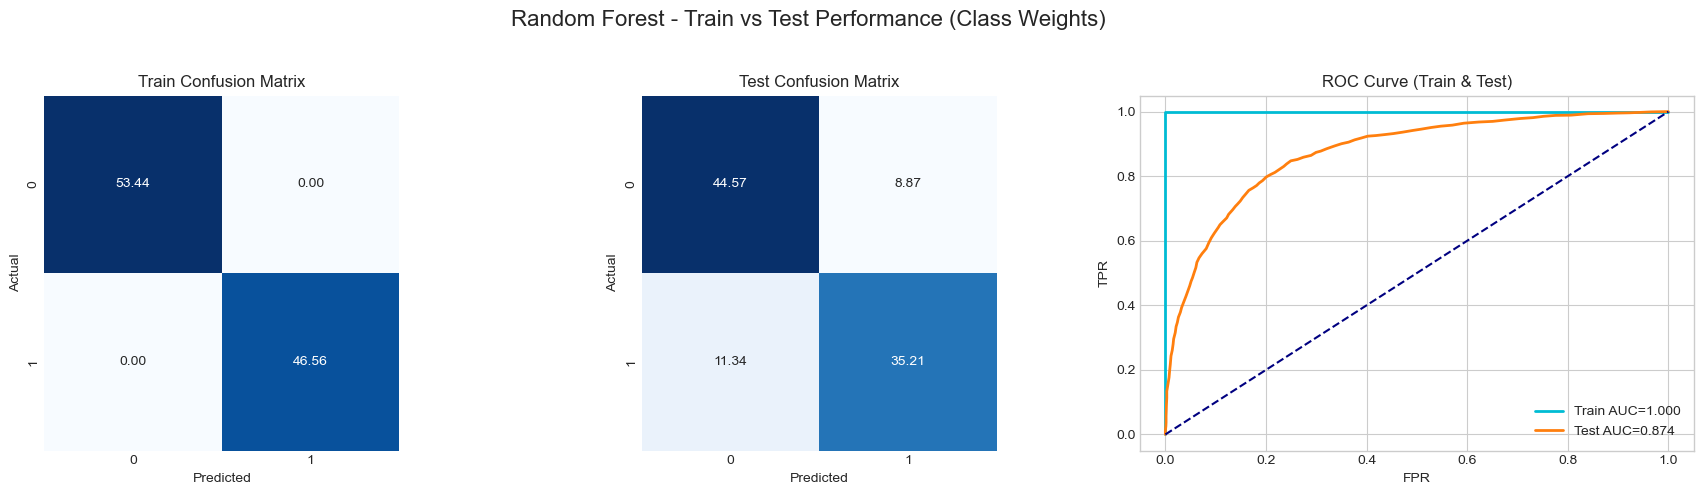

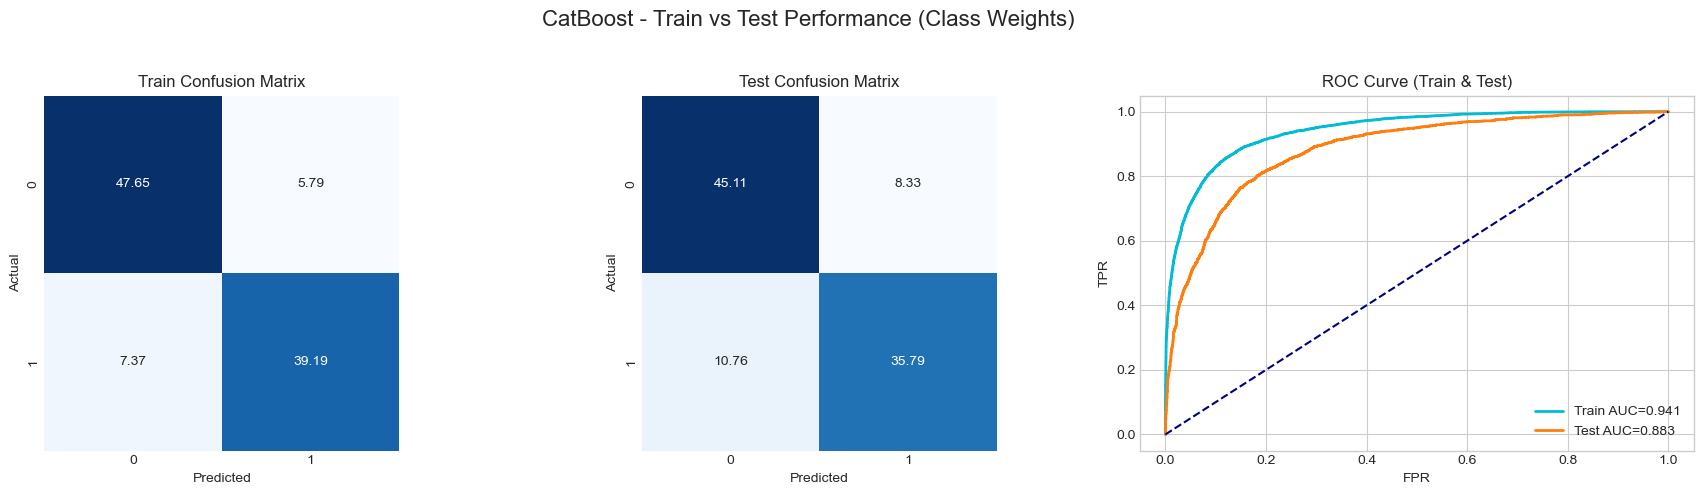

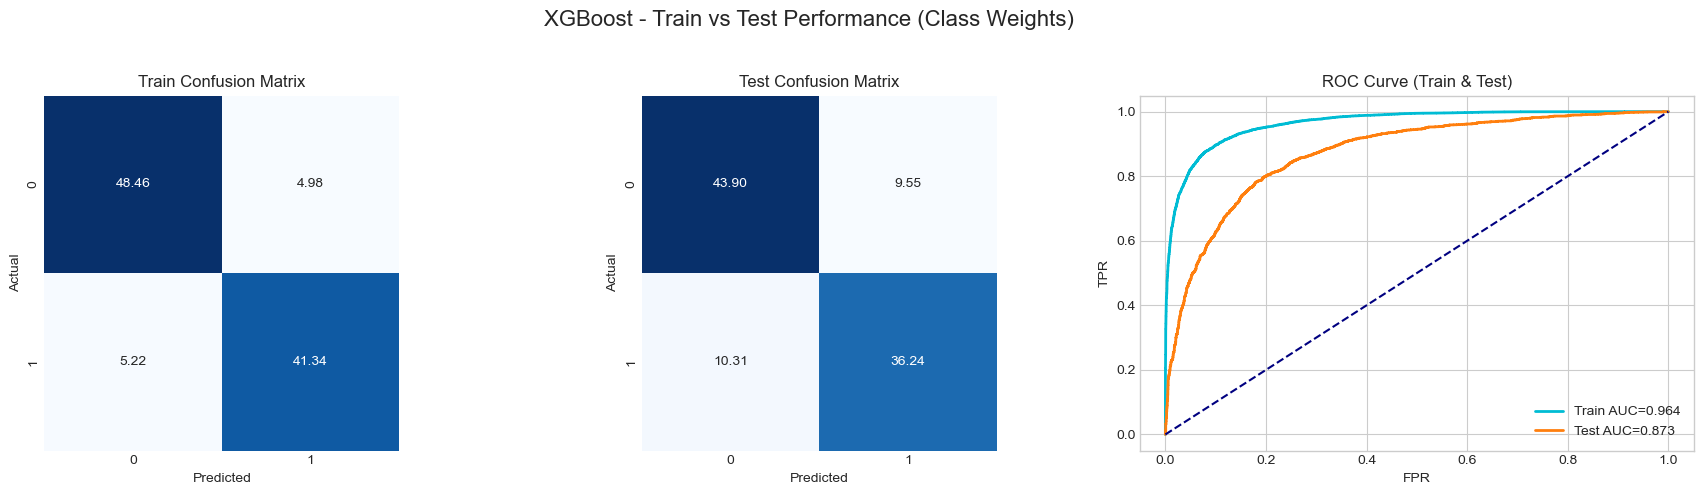

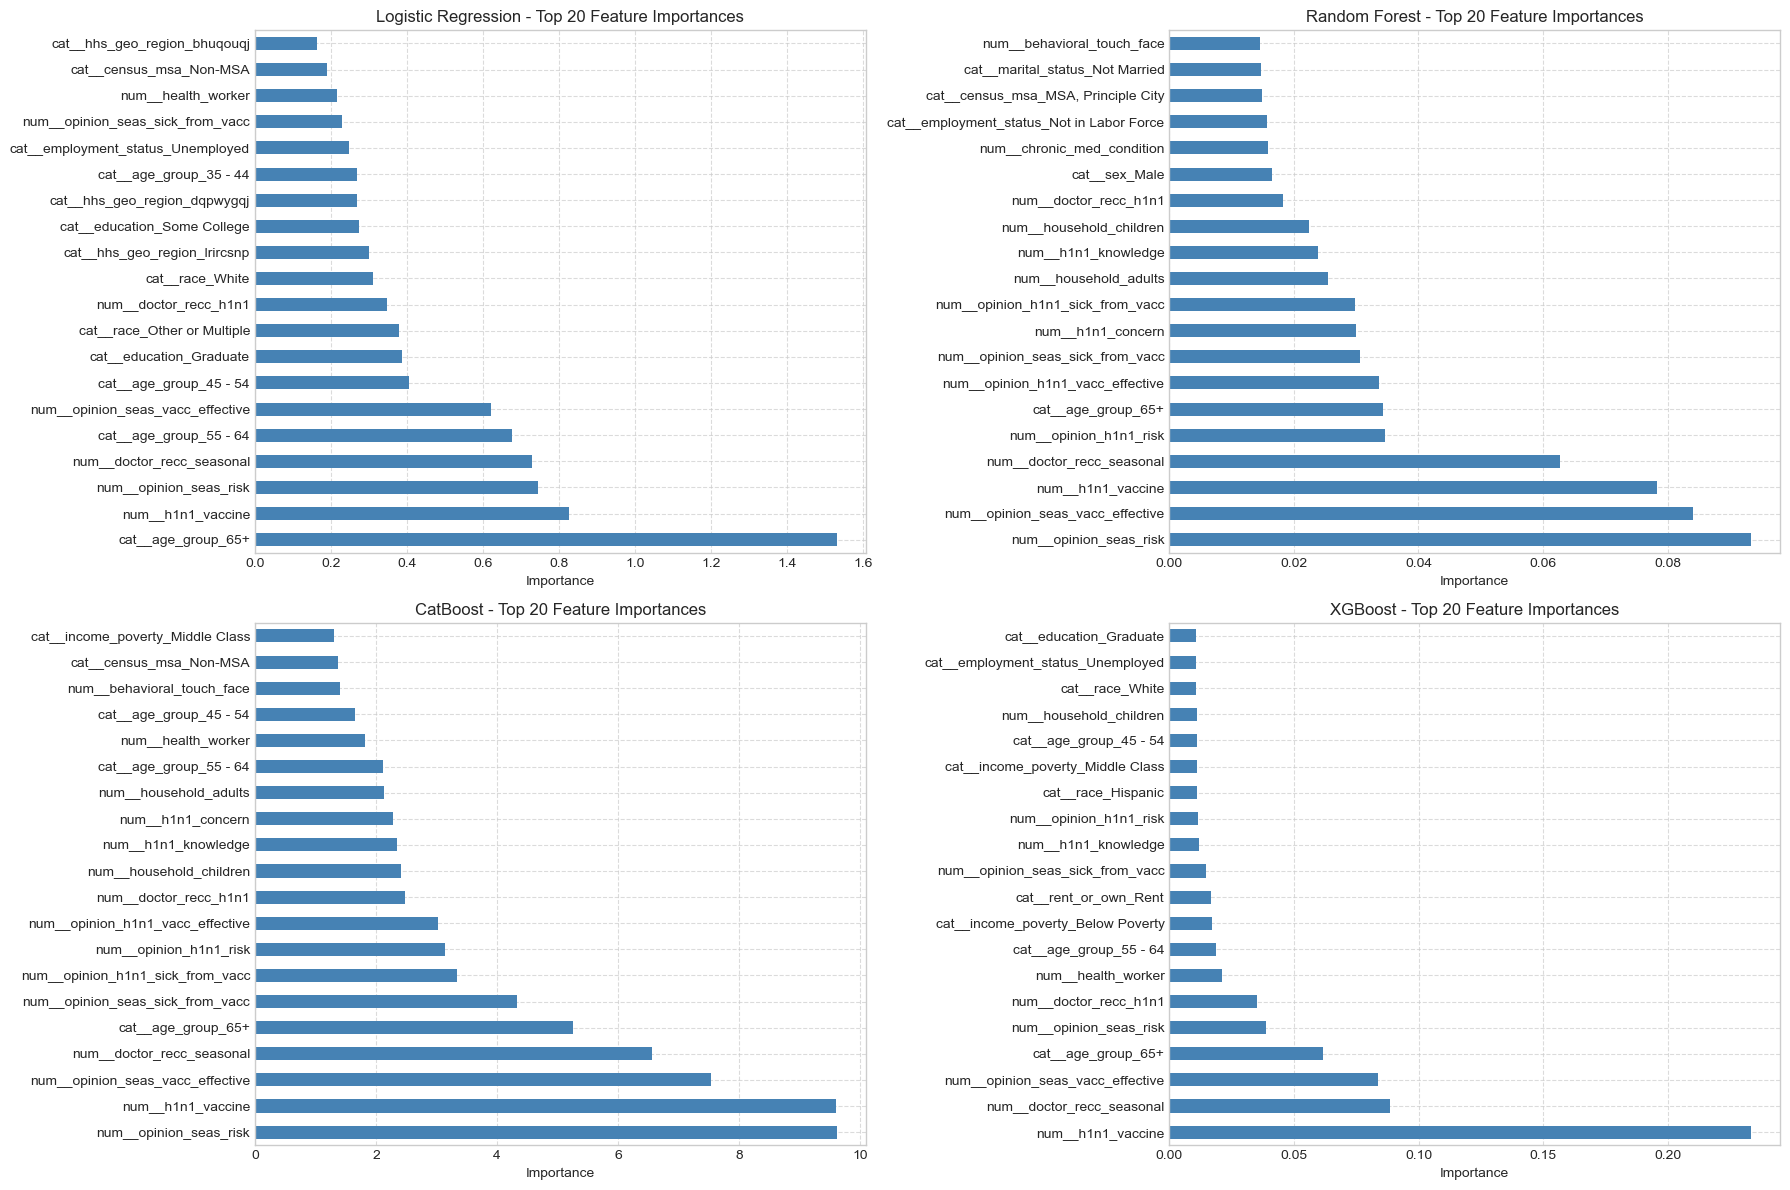

In [14]:
# Compute XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define models with class weighting
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,
        eval_metric='Logloss'
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models and compute metrics
for name, clf in models.items():
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (Class Weights)", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.799757,0.799888,0.799615,0.799728,0.799757,0.799888,0.799638,0.799689,0.874365,0.873248
1,Random Forest,1.000000,0.796331,1.000000,0.796203,1.000000,0.796331,1.000000,0.796019,1.000000,0.871814
2,CatBoost,0.866270,0.808873,0.866294,0.808841,0.866270,0.808873,0.866118,0.808530,0.939260,0.882221
3,XGBoost,0.891406,0.799888,0.891485,0.799958,0.891406,0.799888,0.891287,0.799407,0.958750,0.875752


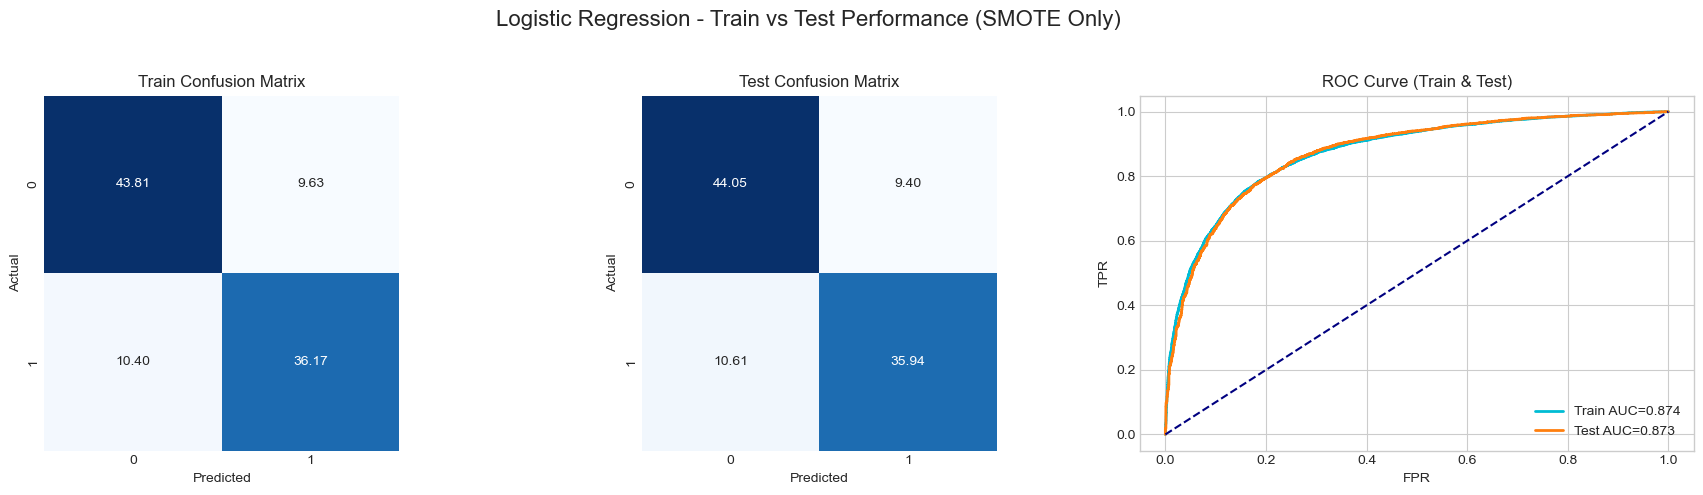

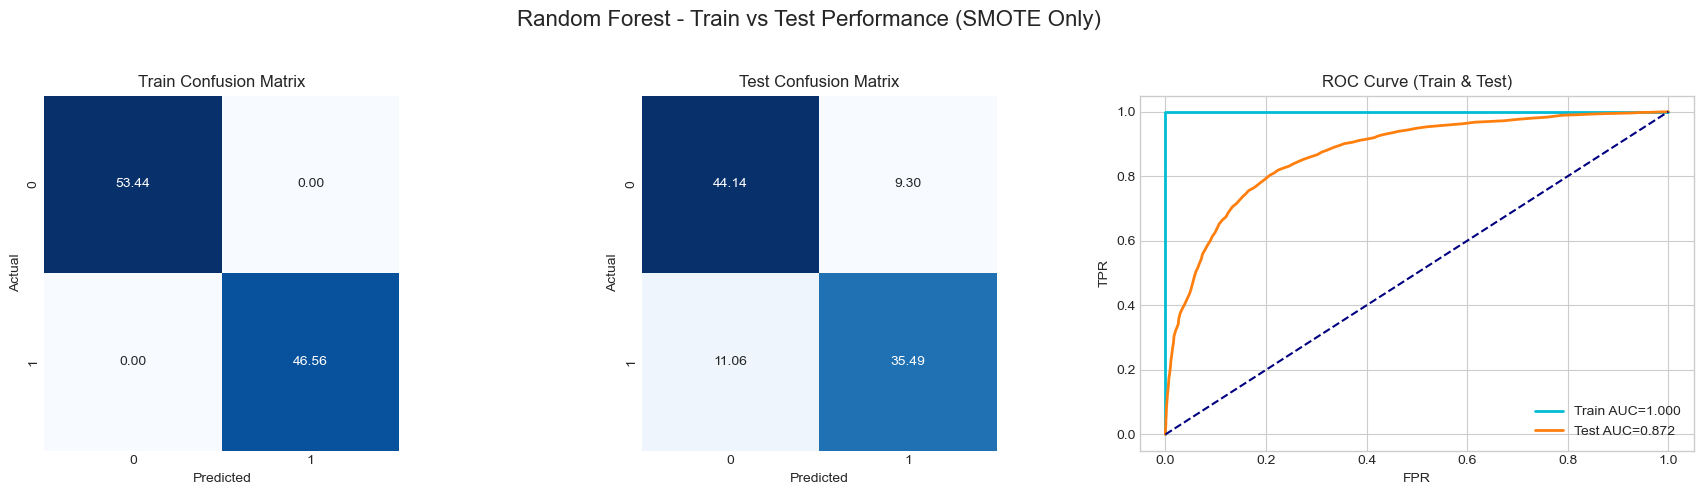

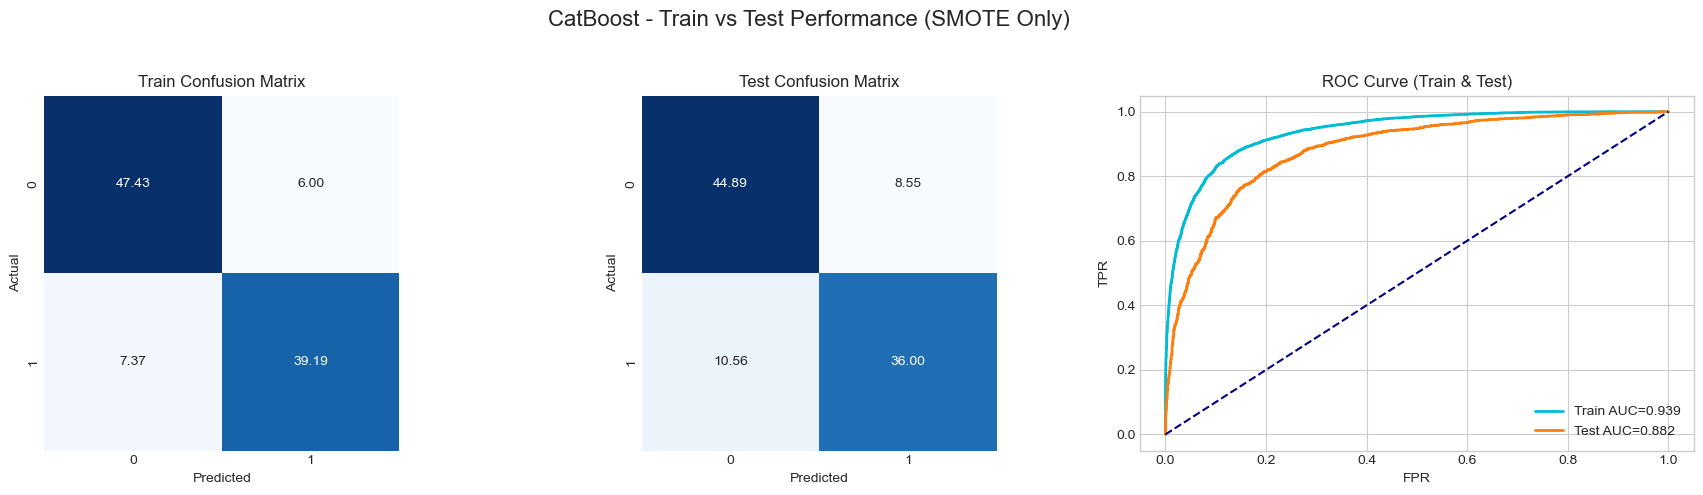

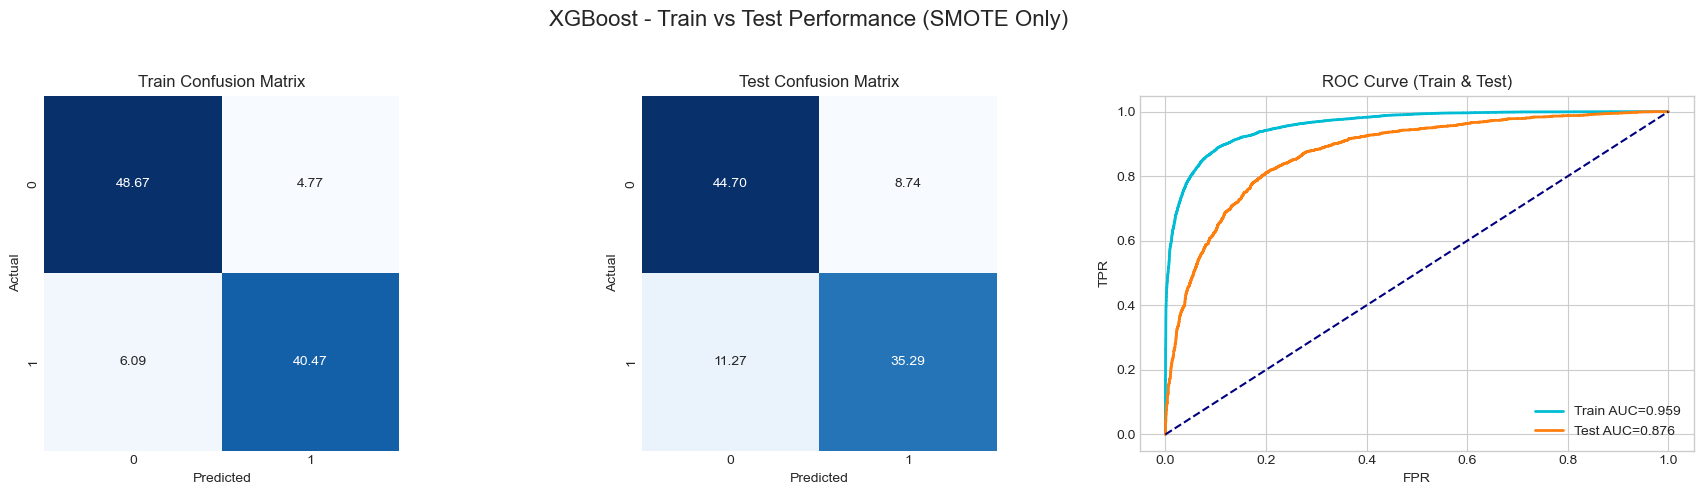

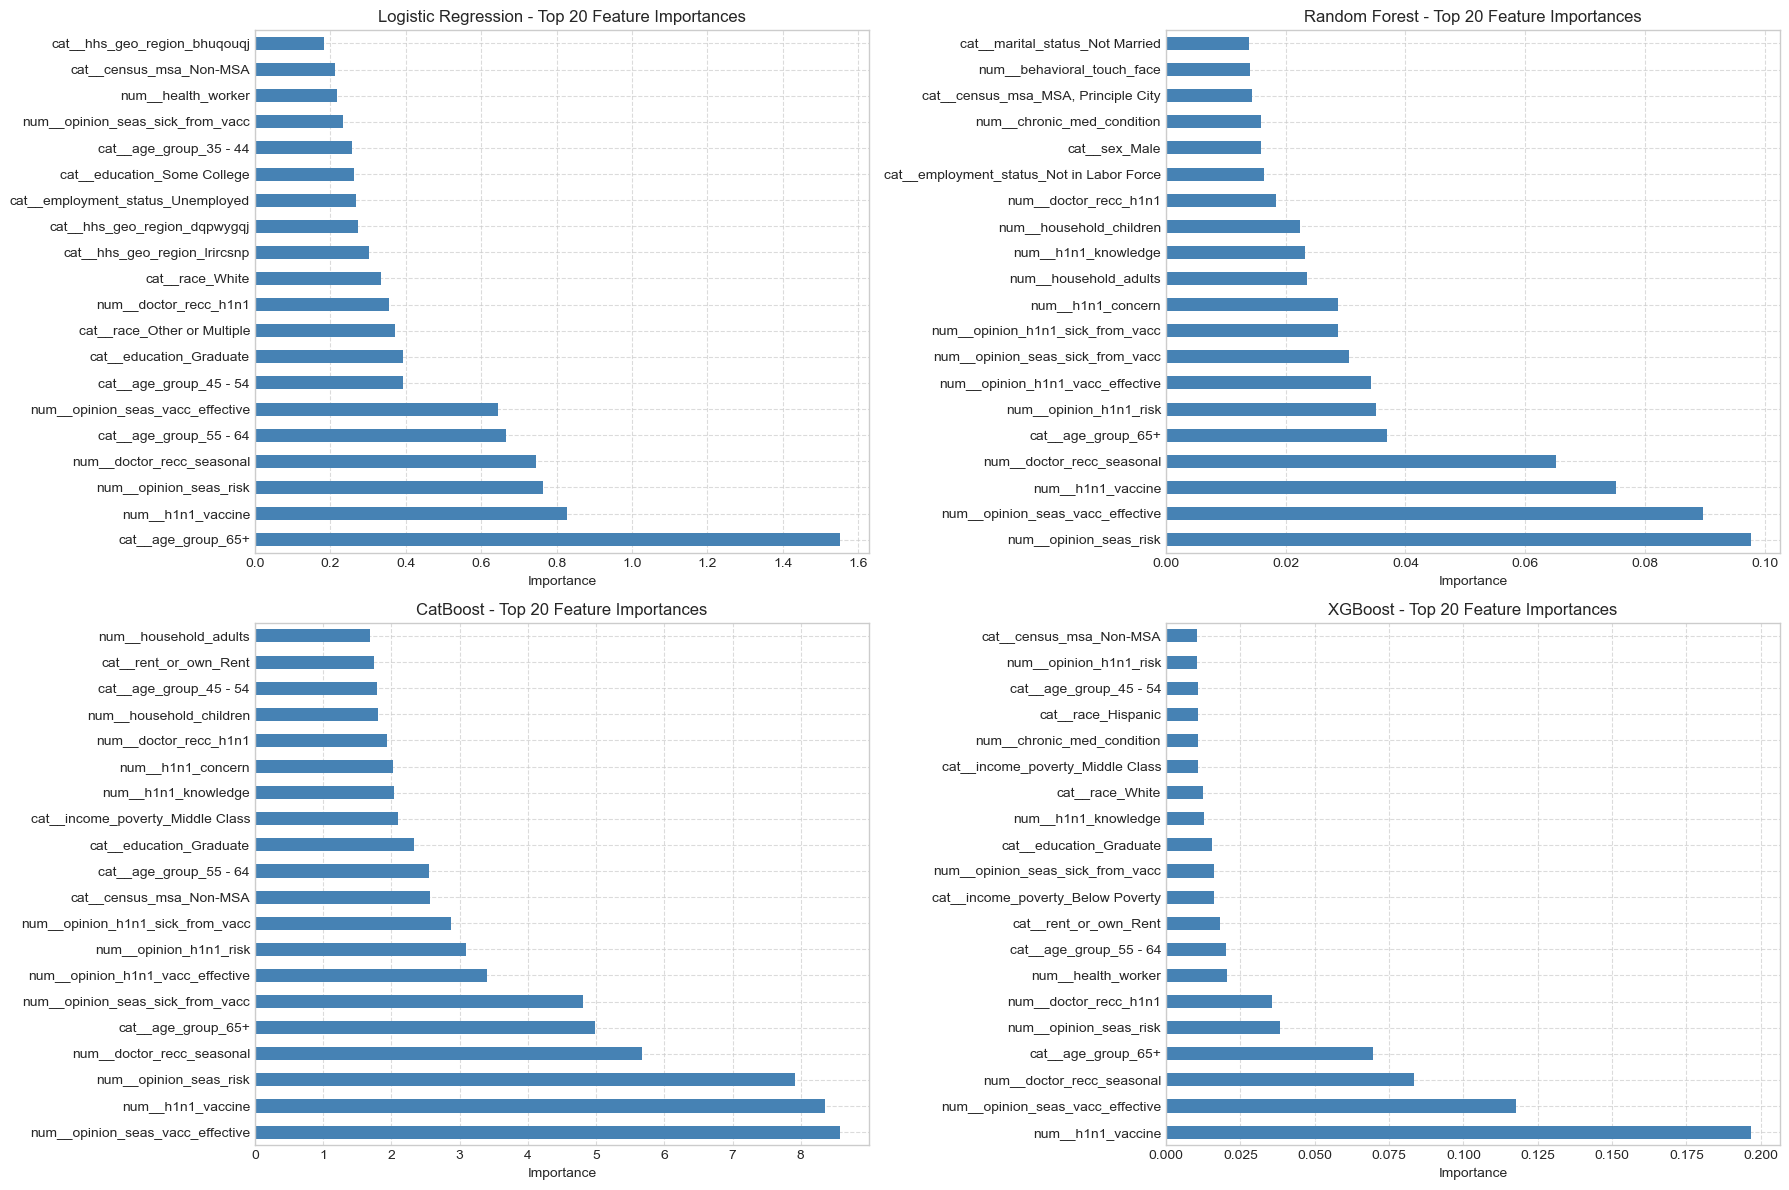

In [15]:
# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(
        random_state=42,
        silent=True,
        eval_metric='Logloss'
    ),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models with SMOTE and compute metrics
for name, clf in models.items():
    
    # Imbalanced pipeline with SMOTE
    pipeline = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    # get feature names from pipeline
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        if name == 'CatBoost':
            importances = pd.Series(final_model.get_feature_importance(), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names)\
                          .sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names)\
                          .sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (SMOTE Only)", fontsize=16)
    
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()